In [1]:
import numpy as np
np.set_printoptions(threshold=np.inf)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import normflows as nf
import random
from torch.utils.data import DataLoader
import pandas as pd
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from scipy.stats import norm

from GPDFlow_S import S_mGPD_NF, ConditionalMaskedAffineFlow, ActNormConditional, ConditionalNormalizingFlow
import Common_Functions as cf
from matplotlib.colors import LinearSegmentedColormap
import scipy.stats as stats

from Common_Functions import empirical_tail_dependence_measure


Using device: cuda


In [2]:
# --- 5-fold cross-validation setup ------------------------------------------
import importlib
import cv_utils
importlib.reload(cv_utils)
from cv_utils import (
    make_folds,
    run_cv_gpdflow_likelihood,
    run_cv_gpdflow_mmd,
    run_cv_flow_baseline,
    run_cv_parametric_mgpd,
    build_probit_copula,
)

SMOKE = False                     # set True for a fast top-to-bottom check
EPOCHS_LIK = 5 if SMOKE else 500
EPOCHS_MMD = 5 if SMOKE else 500
EPOCHS_BL  = 5 if SMOKE else 400
EPOCHS_PAR = 5 if SMOKE else 300
SIM_MULT   = 30                   # simulated rows per fold = SIM_MULT * |fold k|


#### Download exchange rate data from the Bank of England

In [3]:
# BoE website: https://www.bankofengland.co.uk/boeapps/database/Rates.asp?Travel=NIxASx&into=GBP
#
# Python port of the R `pdfetch::pdfetch_BOE` call used to fetch daily GBP exchange
# rates from the Bank of England Interactive Statistical Database (IADB).

import requests
from io import StringIO

# The IADB endpoint 403s on the default python-requests User-Agent, so a
# browser-like one is set explicitly.
_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/120.0 Safari/537.36"
    )
}


def pdfetch_BOE(identifiers, from_date, to_date):
    """Fetch daily series from the Bank of England IADB as a DataFrame indexed by date.

    Mirrors the R `pdfetch::pdfetch_BOE` function, which builds a CSV export URL
    against the BoE IADB `fromshowcolumns.asp` endpoint.
    """
    url = "https://www.bankofengland.co.uk/boeapps/iadb/fromshowcolumns.asp"
    params = {
        "csv.x": "yes",
        "SeriesCodes": ",".join(identifiers),
        "CSVF": "TN",
        "UsingCodes": "Y",
        "VPD": "Y",
        "Datefrom": pd.Timestamp(from_date).strftime("%d/%b/%Y"),
        "Dateto": pd.Timestamp(to_date).strftime("%d/%b/%Y"),
    }
    resp = requests.get(url, params=params, headers=_HEADERS, timeout=60)
    resp.raise_for_status()

    df = pd.read_csv(StringIO(resp.text))
    df[df.columns[0]] = pd.to_datetime(df[df.columns[0]], format="%d %b %Y")
    df = df.set_index(df.columns[0])
    df.index.name = "Date"
    return df


# CHANGED: removed EUR (XUDLERS), SAU (XUDLSRS), USA (XUDLUSS) -- MMD_loss_test.ipynb's
# own pairwise-chi collinearity check (chi >= 0.9) found these three are effectively
# pegged/redundant with currencies already in this list: DNK-EUR (DKK is pegged to EUR),
# and HKG-SAU / HKG-USA / SAU-USA (HKD and SAR are both pegged to USD, so all three move
# almost identically against GBP). Excluding them here means the later
# collinearity-detection cells (further down) should no longer need to drop anything.
identifiers = [
    "XUDLADS", "XUDLCDS", "XUDLBK89", "XUDLBK25", "XUDLDKS",
    "XUDLHDS", "XUDLBK33", "XUDLBK97", "XUDLBK78", "XUDLJYS", "XUDLBK83", "XUDLNDS",
    "XUDLNKS", "XUDLBK47", "XUDLSGS", "XUDLZRS", "XUDLBK93", "XUDLSKS",
    "XUDLSFS", "XUDLTWS", "XUDLBK87", "XUDLBK95",
]

# RUS (XUDLBK85) excluded: the Russian rouble series stops being quoted from
# 2022-03-03 (sanctions) through the end of the sample and never resumes, which
# poisons quantile/tail-dependence computations downstream with NaNs.
ctry_codes = [
    "AUS", "CAN", "CHN", "CZE", "DNK", "HKG", "HUN", "IND", "ISR", "JPN", "MYS",
    "NZL", "NOR", "POL", "SGP", "ZAF", "KOR", "SWE", "CHE", "TWN", "THA",
    "TUR",
]

BoE_exchange_rates = pdfetch_BOE(identifiers, from_date="2005-10-01", to_date="2025-09-30")
BoE_exchange_rates.columns = ctry_codes

BoE_exchange_rates.to_csv("Data_and_Model/BoE_exchange_rates.csv")
BoE_exchange_rates.head()


,AUS,CAN,CHN,CZE,DNK,HKG,HUN,IND,ISR,JPN,...,NOR,POL,SGP,ZAF,KOR,SWE,CHE,TWN,THA,TUR
Date,,,,,,,,,,,,,,,,,,,,,
2005-10-03,2.3038,2.0422,14.1716,43.6484,10.9940,13.6117,369.1584,77.2901,8.0826,200.5332,...,11.5843,5.7735,2.9762,11.2751,1830.9251,13.7283,2.2871,58.3229,72.2895,2.3536
2005-10-04,2.3086,2.0650,14.2249,43.6243,11.0101,13.6611,368.8518,77.8098,8.1082,201.1290,...,11.6437,5.8022,2.9838,11.3518,1836.0510,13.7293,2.2908,58.6436,72.3941,2.3759
2005-10-05,2.3289,2.0802,14.2241,43.6776,10.9935,13.6593,367.4519,77.8846,8.0993,200.5717,...,11.5994,5.7713,2.9803,11.4982,1830.6634,13.7040,2.2827,58.5310,72.2667,2.3836
2005-10-06,2.3406,2.0989,14.3242,43.4247,10.9063,13.7544,366.0575,78.4153,8.1375,201.2568,...,11.5429,5.7428,2.9834,11.5792,1848.8738,13.6244,2.2621,58.9822,72.6869,2.4040
2005-10-07,2.3252,2.0650,14.2127,43.0673,10.8381,13.6466,364.0819,77.9987,8.0774,200.2891,...,11.4720,5.6775,2.9646,11.5371,1825.6888,13.5623,2.2517,58.4766,71.9101,2.3721


#### Preprocess exchange rates: negative log returns and GARCH-filtered residuals

In [4]:
# Negative log returns (nlr), computed column-wise, exactly as R's
# apply(data, 2, FUN = function(x) diff(log(x)))
if "BoE_exchange_rates" not in dir():
    BoE_exchange_rates = pd.read_csv(
        "Data_and_Model/BoE_exchange_rates.csv", index_col="Date", parse_dates=True
    )

data_fx = BoE_exchange_rates

nlr = pd.DataFrame(
    np.diff(np.log(data_fx.values), axis=0),
    columns=data_fx.columns,
    index=data_fx.index[1:],
)

n, d = nlr.shape
n, d


(5051, 22)

In [5]:
# ARMA(0,2)+GARCH(1,1) filtering, fit column-by-column with R's fGarch::garchFit
# via rpy2. Neither `statsmodels` nor the `arch` python package can express a pure
# MA(2) mean term (their mean models only support AR lags), and fGarch performs a
# single joint ARMA-GARCH MLE rather than a two-step fit, so we call R directly to
# match the original R code exactly.
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri, default_converter
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

fGarch = importr("fGarch")
garch_formula = ro.Formula("~arma(0,2)+garch(1,1)")


In [6]:
# Fit each column independently (mirrors the R `for(i in 1:d)` loop). RUS has a
# multi-year gap with no quoted rate (~2022 sanctions), so NAs are dropped per
# column before fitting and the standardized residuals are written back by date.
fit_fGarch = {}
residus = pd.DataFrame(np.nan, index=nlr.index, columns=nlr.columns)

for i, col in enumerate(nlr.columns):
    obs = nlr[col].dropna()

    with localconverter(default_converter + numpy2ri.converter):
        r_x = ro.conversion.py2rpy(obs.to_numpy())
        ga = fGarch.garchFit(garch_formula, data=r_x, trace=False, **{"cond.dist": "norm"})

    resid = np.asarray(ga.slots["residuals"])
    sigma_t = np.asarray(ga.slots["sigma.t"])
    residus.loc[obs.index, col] = resid / sigma_t
    fit_fGarch[col] = ga
    print(f"Done for {i + 1}/{d}")


Done for 1/22
Done for 2/22
Done for 3/22
Done for 4/22
Done for 5/22
Done for 6/22
Done for 7/22
Done for 8/22
Done for 9/22
Done for 10/22
Done for 11/22
Done for 12/22
Done for 13/22
Done for 14/22
Done for 15/22
Done for 16/22
Done for 17/22
Done for 18/22
Done for 19/22
Done for 20/22
Done for 21/22
Done for 22/22


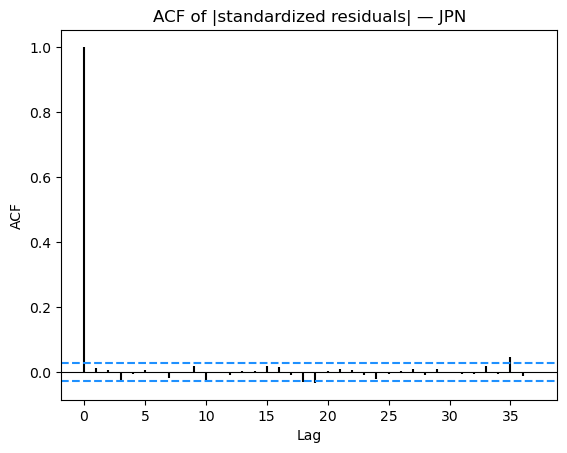

In [7]:
abs_residus = residus.abs()


def acf_plot(x, max_lag=None, ax=None):
    """Sample autocorrelation bar plot with 95% white-noise bounds, mirroring R's acf()."""
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    n_obs = len(x)
    if max_lag is None:
        max_lag = int(10 * np.log10(n_obs))
    x_c = x - x.mean()
    denom = np.sum(x_c**2)
    acf_vals = np.array(
        [1.0] + [np.sum(x_c[lag:] * x_c[:-lag]) / denom for lag in range(1, max_lag + 1)]
    )

    ax = ax or plt.gca()
    ax.vlines(np.arange(max_lag + 1), 0, acf_vals, color="black")
    ax.axhline(0, color="black", linewidth=0.8)
    bound = 1.96 / np.sqrt(n_obs)
    ax.axhline(bound, color="dodgerblue", linestyle="--")
    ax.axhline(-bound, color="dodgerblue", linestyle="--")
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
    return acf_vals


# R's abs.residus[,10] is the 10th (1-indexed) column -> Python column index 9
acf_plot(abs_residus.iloc[:, 9])
plt.title(f"ACF of |standardized residuals| — {abs_residus.columns[9]}")
plt.show()


#### Define a GPDFlow

In [8]:
dir_out = "/home/pgrad2/2448355h/My_PhD_Project/GPDFlow/Data_and_Model/"



#### Find a suitable threshold for the simulated data

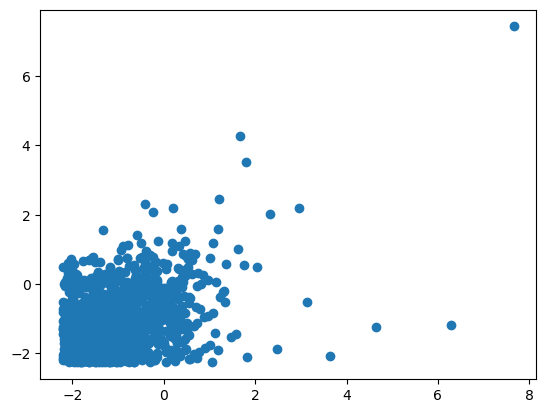

In [9]:
samples_origin = abs_residus.values[:,:]

# Threshold quantile: defines the exceedance slice AND the level at which the
# tail-dependence diagnostics (chi / omega) are evaluated throughout the notebook.
THRESHOLD_Q = 0.97

thres = np.quantile(samples_origin, THRESHOLD_Q, axis=0)

cond = np.any(samples_origin > thres, axis=1)
samples = samples_origin[cond,:]

thres = thres.reshape(1,-1)
samples = samples - thres

plt.scatter(samples[:,0],samples[:,1] )


In [10]:
samples.shape

(1288, 22)

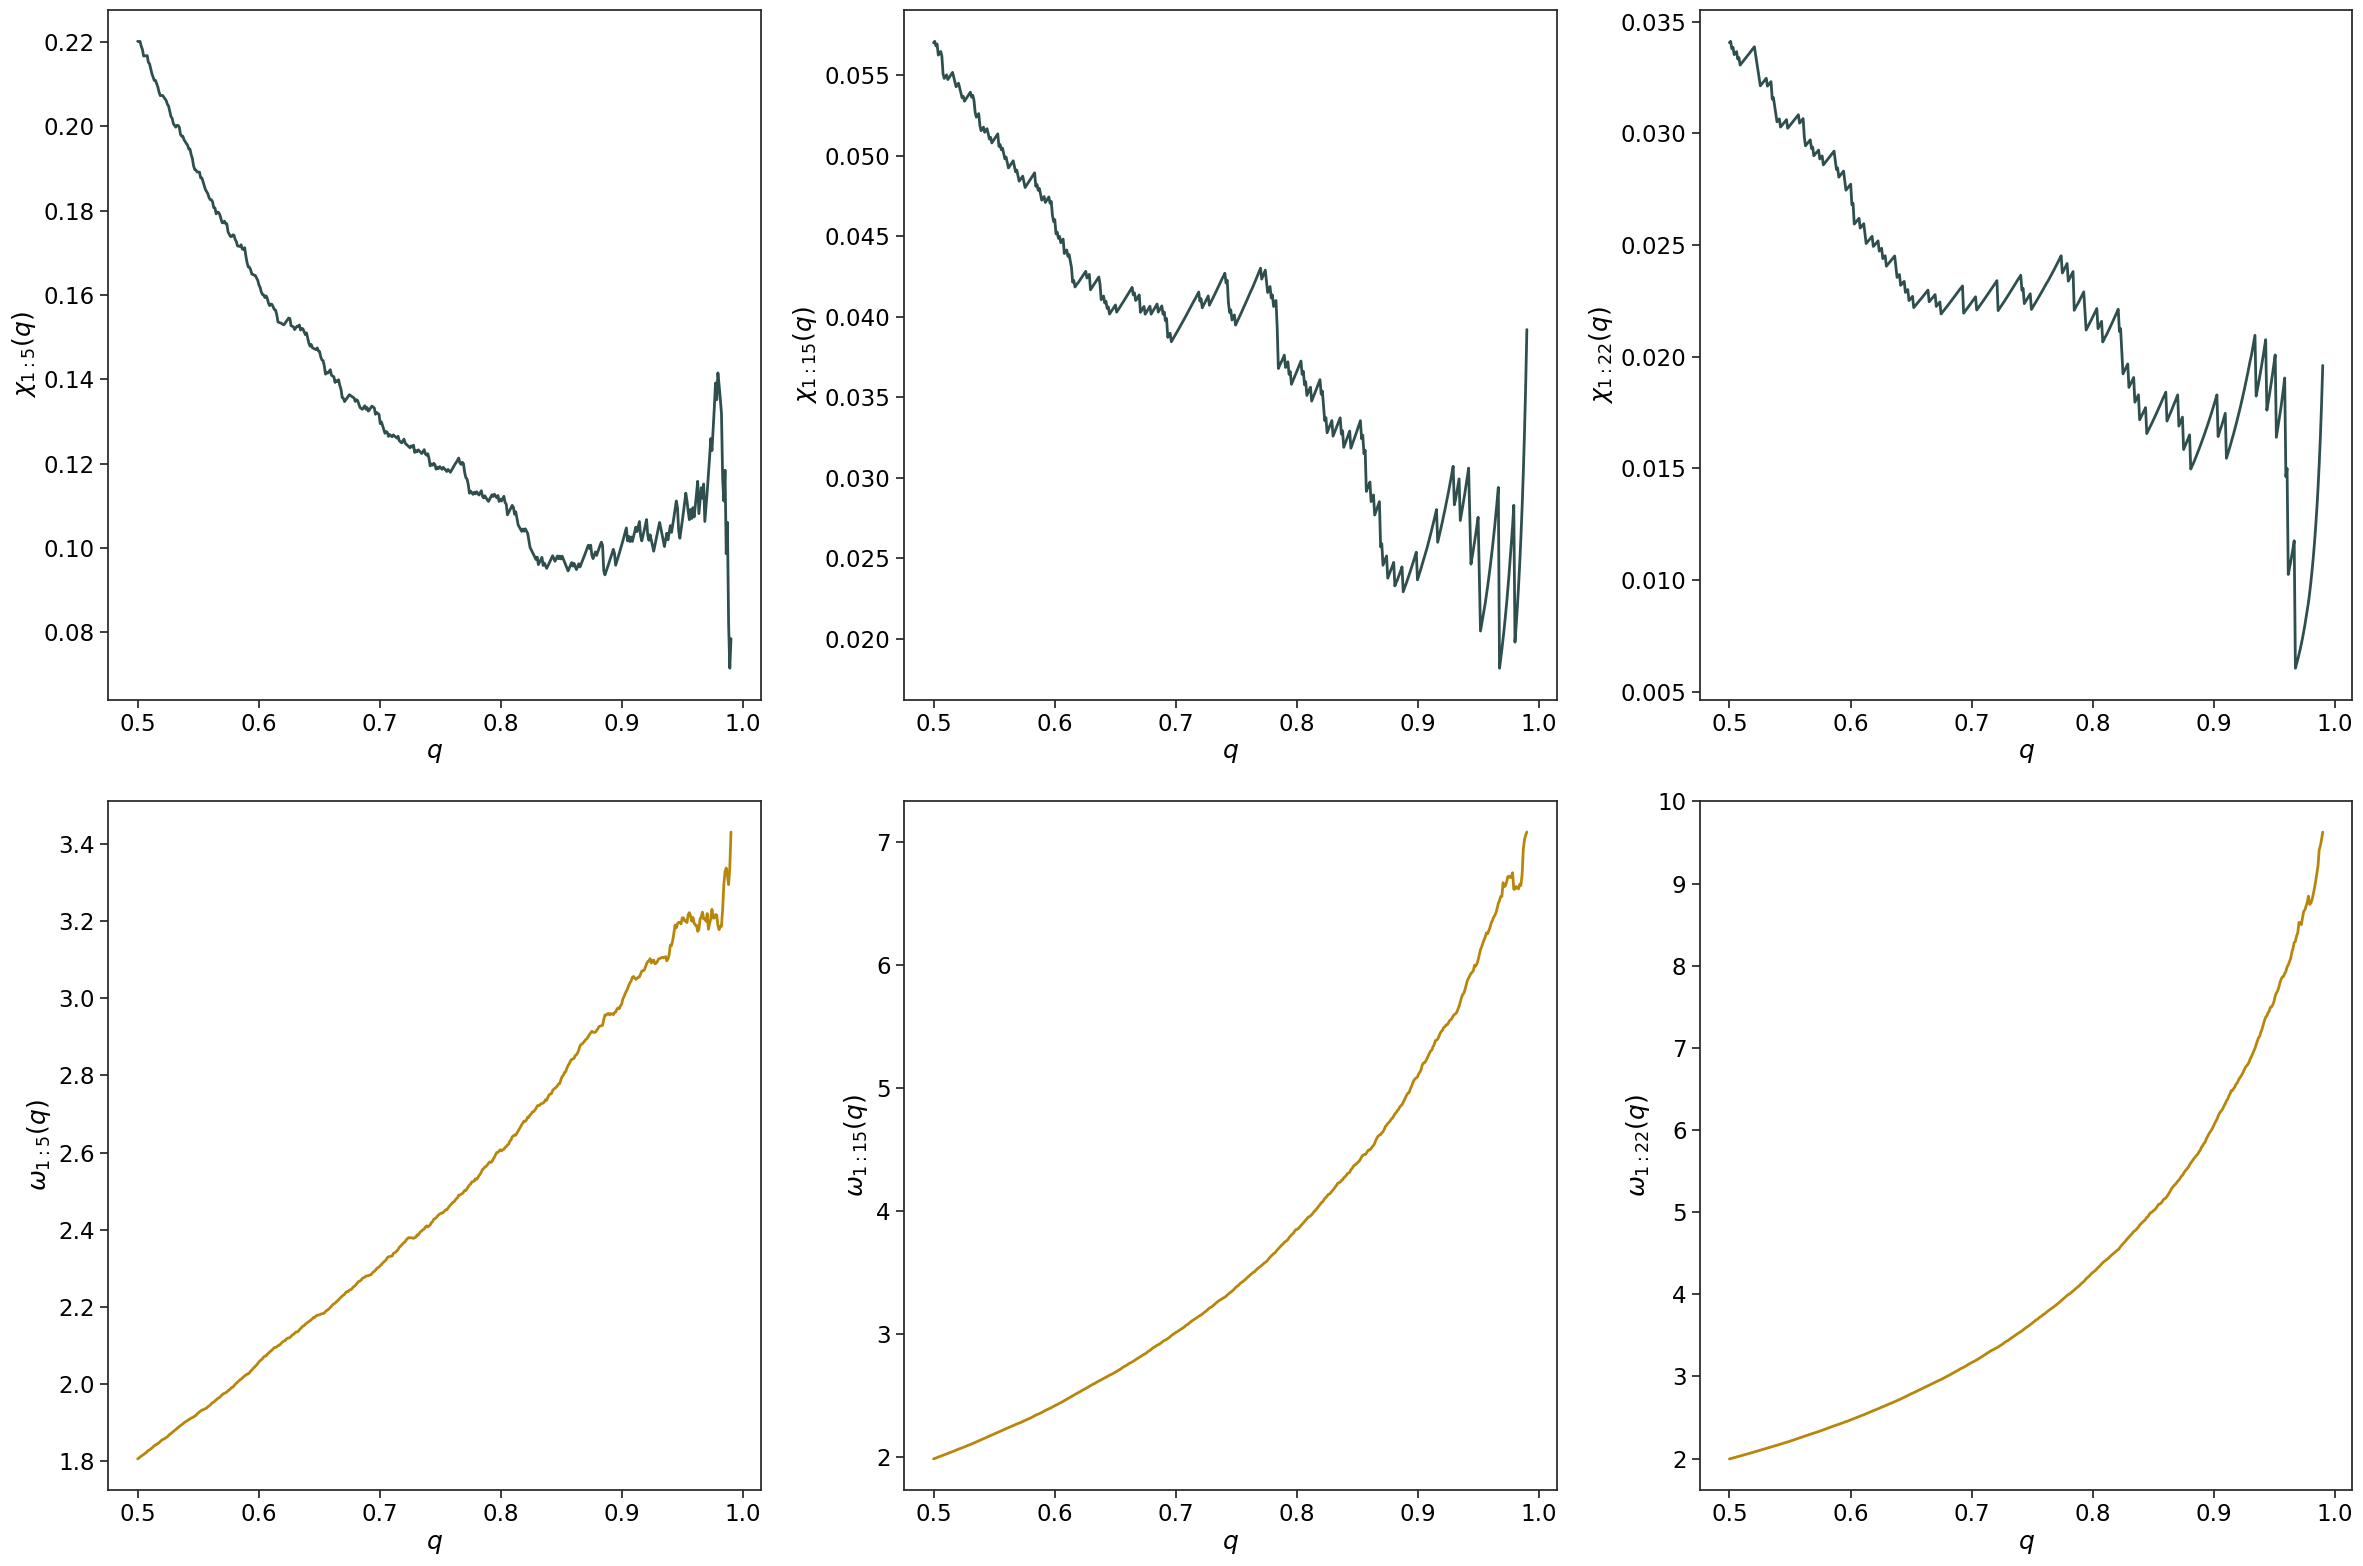

In [11]:
probs = np.linspace(0.5, 0.99, 500)
col_counts = [5, 15, 22]  # CHANGED: was 25 -- 22 columns after removing pegged currencies

chi_emp = {
    k: [empirical_tail_dependence_measure(samples_origin[:, :k], p, 'and') for p in probs]
    for k in col_counts
}
omega_emp = {
    k: [empirical_tail_dependence_measure(samples_origin[:, :k], p, 'or') for p in probs]
    for k in col_counts
}

# 2x3 grid: chi(q) on row 1, omega(q) on row 2, one column per subset size
sns.set(style="ticks", font_scale=1.5)
color_chi = 'darkslategray'
color_omega = 'darkgoldenrod'

fig, axes = plt.subplots(2, 3, figsize=(24, 16))

for col, k in enumerate(col_counts):
    ax = axes[0, col]
    ax.plot(probs, chi_emp[k], color=color_chi, linewidth=2)
    ax.set_xlabel(r'$q$', color='black')
    ax.set_ylabel(rf'$\chi_{{1:{k}}}(q)$', color='black')
    ax.tick_params(axis='both', labelcolor='black')

    ax = axes[1, col]
    ax.plot(probs, omega_emp[k], color=color_omega, linewidth=2)
    ax.set_xlabel(r'$q$', color='black')
    ax.set_ylabel(rf'$\omega_{{1:{k}}}(q)$', color='black')
    ax.tick_params(axis='both', labelcolor='black')

fig.tight_layout()
plt.savefig(dir_out + 'Plots/'+'threshold_selection.pdf',bbox_inches='tight')
plt.show()

In [12]:
seed = 1234
rng = np.random.default_rng(seed)  # set seed for reproducibility (change/remove if you want)
idx = rng.permutation(len(samples))

split = int(0.8 * len(samples))
train_idx, val_idx = idx[:split], idx[split:]

train_samples = samples[train_idx]
val_samples   = samples[val_idx]

In [13]:
# Partition the exceedance slice into 5 CV folds. The same `folds` object is
# reused by the likelihood, MMD and baseline fits so their out-of-fold simulated
# sets are mutually comparable. The single 80/20 train_samples/val_samples split
# above is kept -- it still feeds the parametric-mGPD section and the copula
# diagnostic cell.
folds = make_folds(len(samples), n_splits=5, seed=1234)
print('fold val sizes:', [len(v) for _, v in folds])


fold val sizes: [258, 258, 258, 257, 257]


In [14]:
train_samples.shape

(1030, 22)

# Joint fit with likelihood based approach

In [15]:
# --- Likelihood-based GPDFlow, 5-fold cross-validation ---------------------
# For fold k: train on the other 4 folds, early-stop on fold k (patience 100 on
# the validation NLL), then draw SIM_MULT * |fold k| observations from the
# fold-k model.  cv_utils keeps the 5 out-of-fold blocks SEPARATE
# (`samples_simu_folds`, raw scale) and computes NO tail-dependence summary --
# chi / omega are formed here, so the evaluation threshold can be changed
# without refitting.
dim = samples.shape[1]
p_cluster = samples.shape[0] / samples_origin.shape[0]
p_sim_q = 1.0 - (1.0 - THRESHOLD_Q) / p_cluster    # cluster-conditional level matching q = THRESHOLD_Q

# Shared flow / penalty config: used by BOTH the CV below and the final
# full-data fit, so the two can never drift (arch = hparam-sweep winner L4/lsf3).
LIK_CFG = dict(
    num_layers=4, latent_size_factor=3,
    penalty_lambda=1e4, marg_lambda=300,
    seed=1234,
)


def cv_pairwise_chi(fold_blocks, p):
    """Mean over CV folds of each fold model's rank-based pairwise chi at level p
    (folds are NOT pooled -- a pool of 5 separately fitted flows is a mixture)."""
    return np.mean([cf.pairwise_chi_from_data(b, p=p) for b in fold_blocks], axis=0)


def cv_pairwise_omega(fold_blocks, p):
    return np.mean([cf.pairwise_omega_from_data(b, p=p) for b in fold_blocks], axis=0)


cv_like = run_cv_gpdflow_likelihood(
    samples, folds, device, thres,
    epochs=EPOCHS_LIK, samples_multiplier=SIM_MULT,
    patience=100, **LIK_CFG,
)

print('p_cluster =', round(p_cluster, 4), ' p_sim_q =', round(p_sim_q, 4))
print('per-fold best val NLL :', np.round(cv_like['best_vals'], 4))
print('per-fold best epoch   :', [h['best_epoch'] for h in cv_like['hist']])
print('fold-mean sigma_hat   :', np.round(cv_like['sigma_hat'], 3))
print('fold-mean gamma_hat   :', np.round(cv_like['gamma_hat'], 3))


[likelihood] fold 1/5 (train 1030, val 258)


  scipy margin init  gamma~[0.271 0.244 0.212 0.173 0.182 0.183 0.176 0.115 0.18  0.242 0.17  0.178
 0.297 0.127 0.114 0.416 0.236 0.063 0.182 0.147 0.26  0.227]
  scipy margin init  sigma~[0.536 0.453 0.445 0.602 0.497 0.499 0.479 0.534 0.526 0.555 0.505 0.554
 0.409 0.516 0.575 0.332 0.37  0.588 0.52  0.515 0.5   0.65 ]
  epoch    1/500 | train=222.8110 | val=220.4522 | val_nll=36.2221
  epoch   25/500 | train=182.1698 | val=174.6075 | val_nll=29.1091
  epoch   50/500 | train=175.4206 | val=167.9393 | val_nll=25.4055
  epoch   75/500 | train=173.0621 | val=170.4469 | val_nll=24.7408
  epoch  100/500 | train=171.7643 | val=168.4878 | val_nll=24.4671
  epoch  125/500 | train=169.0795 | val=167.8456 | val_nll=24.1567
  epoch  150/500 | train=174.9725 | val=167.0980 | val_nll=24.0655
  epoch  175/500 | train=168.5476 | val=168.1868 | val_nll=25.3125
  early stopping at epoch 185 (best val NLL @ 85).
[likelihood] fold 2/5 (train 1030, val 258)
  scipy margin init  gamma~[0.225 0.255 0.287

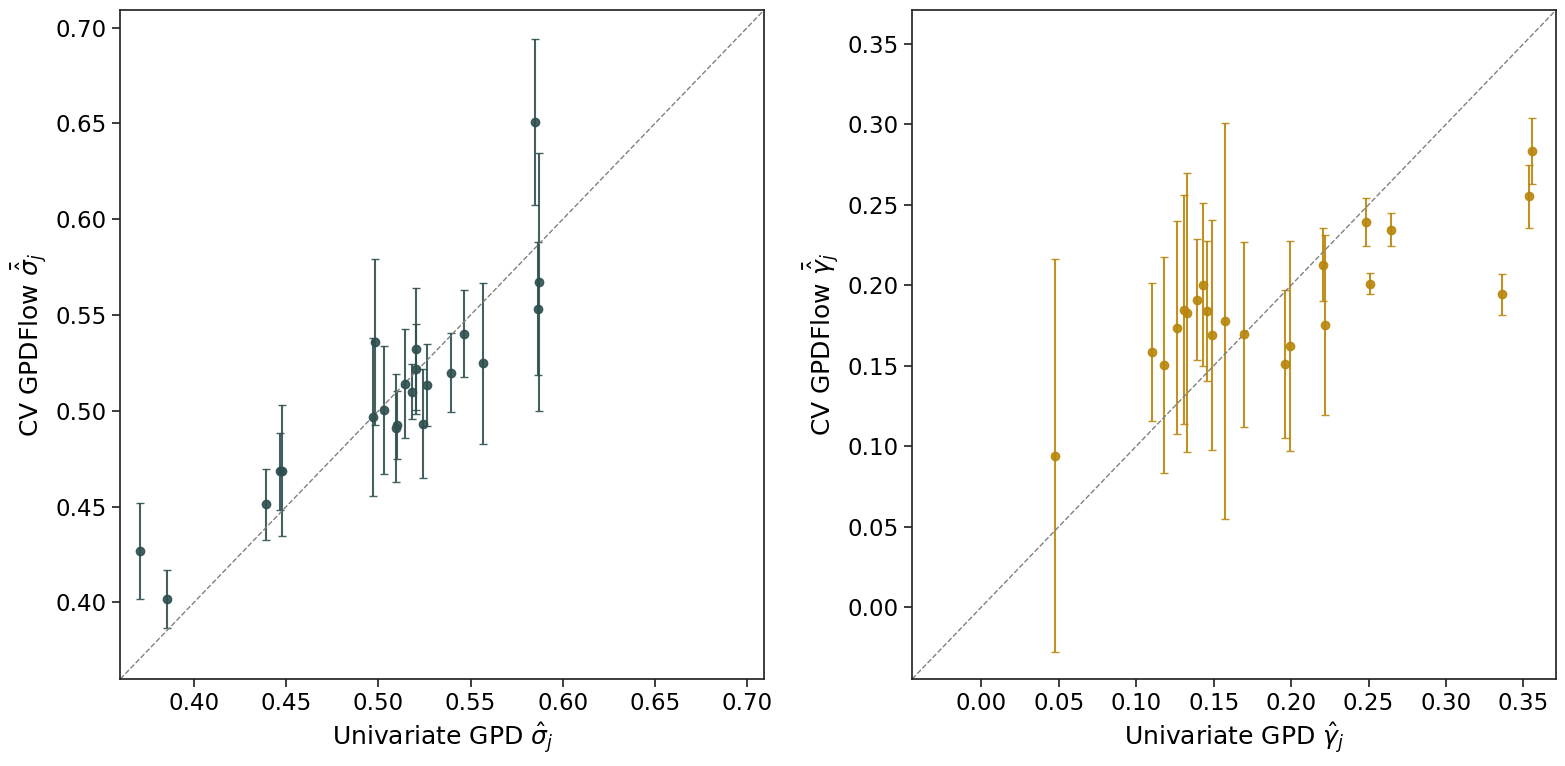

In [16]:
# Univariate GPD per margin vs the CROSS-VALIDATED GPDFlow marginal estimates.
# y-axis: mean over the 5 folds of the fitted sigma_j / gamma_j (arithmetic mean
# of sigma; the geometric mean exp(mean(log sigma)) is within ~1% here). Error
# bars are the across-fold standard deviation.
# x-axis: a univariate scipy GPD fit on the full slice `samples` (fold-independent
# reference).
sigma_hat = cv_like['sigma_hat']
gamma_hat = cv_like['gamma_hat']
sigma_hat_folds = cv_like['sigma_hat_folds']
gamma_hat_folds = cv_like['gamma_hat_folds']

uni_sigmas = []
uni_gammas = []
for i in range(dim):
    data_i = samples[samples[:, i] > 0, i]
    c, loc, scale = stats.genpareto.fit(data_i, floc=0)
    uni_gammas.append(c)
    uni_sigmas.append(scale)
uni_sigmas = np.array(uni_sigmas)
uni_gammas = np.array(uni_gammas)

sns.set(style="ticks", font_scale=1.5)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

ax = axes[0]
ax.errorbar(uni_sigmas, sigma_hat, yerr=sigma_hat_folds.std(axis=0),
            fmt='o', color='darkslategray', ecolor='darkslategray',
            alpha=0.9, capsize=3)
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Univariate GPD $\hat{\sigma}_j$', color='black')
ax.set_ylabel(r'CV GPDFlow $\bar{\hat{\sigma}}_j$', color='black')
ax.tick_params(axis='both', labelcolor='black')

ax = axes[1]
ax.errorbar(uni_gammas, gamma_hat, yerr=gamma_hat_folds.std(axis=0),
            fmt='o', color='darkgoldenrod', ecolor='darkgoldenrod',
            alpha=0.9, capsize=3)
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Univariate GPD $\hat{\gamma}_j$', color='black')
ax.set_ylabel(r'CV GPDFlow $\bar{\hat{\gamma}}_j$', color='black')
ax.tick_params(axis='both', labelcolor='black')

fig.tight_layout()
plt.show()


In [17]:
# Pairwise chi: empirical "truth" (samples_origin, q = THRESHOLD_Q) vs the mean over the
# 5 CV folds of each fold model's pairwise_chi_from_data, evaluated at the
# matching cluster-conditional level p_sim_q = 1 - (1 - THRESHOLD_Q) / p_cluster.
# Computed from cv_like['samples_simu_folds'] (not inside the CV driver) so the
# threshold is a free knob.
chi_true = cf.pairwise_chi_from_data(samples_origin, p=THRESHOLD_Q)
chi_hat = cv_pairwise_chi(cv_like['samples_simu_folds'], p_sim_q)
print('p_sim_q =', round(p_sim_q, 4), '  TDE_chi =', round(cf.tde_chi(chi_hat, chi_true), 4))


p_sim_q = 0.8824   TDE_chi = 0.0364


CV chi_{0,1}(q): mean |gap| vs empirical over q in [0.970, 0.999]  =  0.0204


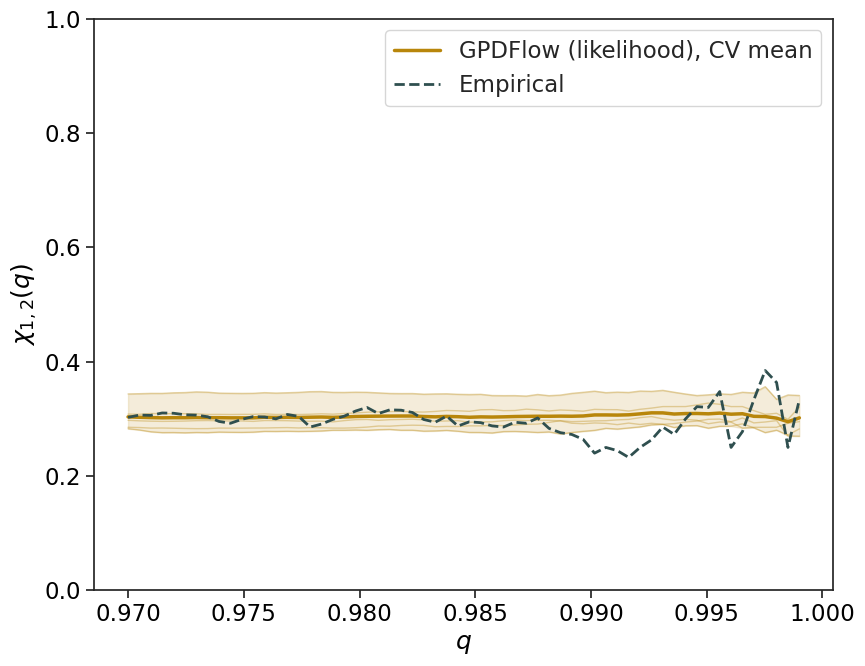

In [18]:
# ---------------------------------------------------------------------------
# chi_{ij}(q) for the likelihood-based GPDFlow  --  pair (i, j) = (0, 1)
# ---------------------------------------------------------------------------
# Three fixes vs. the old chi_{1:k}(q) overlay:
#
#  1. Shared absolute threshold.  empirical_tail_dependence_measure takes the
#     q-quantile *of whatever array it is handed*.  The GPDFlow draws are all
#     cluster exceedances (`samples` = np.any(samples_origin > thres) slice), so
#     their q-quantile sits at a *cluster-conditional* level while the empirical
#     q-quantile is unconditional -> the two curves were being measured at
#     different absolute thresholds (this is the "gap").  For any q >= THRESHOLD_Q,
#     exceeding margin i's q-quantile u_i(q) implies the cluster event, so
#         P(X_i > u_i(q)) = p_cluster * P_cluster(X_i > u_i(q))
#     and the cluster-conditional sample's p_sim-quantile equals u_i(q) with
#         p_sim(q) = 1 - (1 - q) / p_cluster
#     (one scalar, valid for every margin simultaneously).  Evaluating the model
#     draws at p_sim(q) and the empirical data at q puts both on the SAME
#     threshold.  chi is a conditional ratio, so p_cluster cancels -- no extra
#     multiplicative factor is applied to chi itself.
#
#  2. Pairwise, not chi_{1:k}.  chi_{1:22}(q) = P(all 22 exceed | margin 1) is ~0
#     near q -> 1 for any model (the empirical curve is degenerate there too);
#     the mGPD threshold-stability property is about pairwise chi.  Pair (0, 1).
#
#  3. CV structure.  cv_utils keeps the 5 out-of-fold draw blocks SEPARATE
#     (`samples_simu_folds`) -- a pool of draws from 5 separately fitted flows
#     is a mixture, not an mGPD.  Here we take chi_{01}(q) from each fold model
#     and average the 5 curves -> the "CV chi(q)" model-selection quantity.
i, j = 0, 1
p_cluster = samples.shape[0] / samples_origin.shape[0]
q_grid = np.linspace(max(THRESHOLD_Q, 1.0 - p_cluster + 1e-3), 0.999, 60)

chi_emp_ij = np.array([
    empirical_tail_dependence_measure(samples_origin[:, [i, j]], q, 'and')
    for q in q_grid
])


def chi_model_ij(X_raw, q_grid=q_grid, p_cluster=p_cluster, i=i, j=j):
    """chi_{ij}(q) from cluster-conditional raw-scale draws, re-levelled to the
    unconditional q via p_sim = 1 - (1 - q) / p_cluster (shared threshold)."""
    out = np.full(len(q_grid), np.nan)
    for t, q in enumerate(q_grid):
        p_sim = 1.0 - (1.0 - q) / p_cluster
        if not (0.0 < p_sim < 1.0):
            continue
        out[t] = empirical_tail_dependence_measure(X_raw[:, [i, j]], p_sim, 'and')
    return out


fold_curves = []
for m in cv_like['models']:
    m.eval()
    with torch.no_grad():
        xs, _, _ = m.sample(100_000)
    fold_curves.append(chi_model_ij(xs.cpu().numpy() + thres))
fold_curves = np.array(fold_curves)                      # (n_folds, len(q_grid))
chi_cv_ij = np.nanmean(fold_curves, axis=0)              # CV chi_{01}(q)

D = float(np.nanmean(np.abs(chi_cv_ij - chi_emp_ij)))
print(f'CV chi_{{{i},{j}}}(q): mean |gap| vs empirical over '
      f'q in [{q_grid[0]:.3f}, {q_grid[-1]:.3f}]  =  {D:.4f}')

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(9, 7))
for c in fold_curves:
    ax.plot(q_grid, c, color='darkgoldenrod', linewidth=1, alpha=0.35)
ax.fill_between(q_grid, np.nanmin(fold_curves, axis=0), np.nanmax(fold_curves, axis=0),
                color='darkgoldenrod', alpha=0.15)
ax.plot(q_grid, chi_cv_ij, color='darkgoldenrod', linewidth=2.5,
        label='GPDFlow (likelihood), CV mean')
ax.plot(q_grid, chi_emp_ij, color='darkslategray', linewidth=2, linestyle='--',
        label='Empirical')
ax.set_xlabel(r'$q$', color='black')
ax.set_ylabel(rf'$\chi_{{{i + 1},{j + 1}}}(q)$', color='black')
ax.set_ylim(0, 1)
ax.tick_params(axis='both', labelcolor='black')
ax.legend()
fig.tight_layout()
plt.show()


per-fold early-stop epochs: [85, 120, 123, 115, 62] -> median: 115
  scipy margin init  gamma~[0.248 0.251 0.199 0.157 0.17  0.149 0.133 0.11  0.131 0.264 0.139 0.146
 0.222 0.143 0.118 0.336 0.196 0.048 0.353 0.126 0.22  0.356]
  scipy margin init  sigma~[0.521 0.439 0.448 0.587 0.497 0.503 0.51  0.524 0.557 0.52  0.51  0.539
 0.447 0.527 0.546 0.371 0.385 0.587 0.498 0.515 0.518 0.585]


  epoch    1/500 | train=224.0447 | val=220.0380 | val_nll=35.0026
  epoch   25/500 | train=177.4148 | val=177.4347 | val_nll=24.2126
  epoch   50/500 | train=170.1767 | val=173.5332 | val_nll=21.0981
  epoch   75/500 | train=172.5071 | val=172.4040 | val_nll=19.8934
  epoch  100/500 | train=174.4754 | val=171.8619 | val_nll=19.0783
  stopping at fixed epoch 115 (stop_at_epoch).
final-model chi_{0,1}(q): mean |gap| vs empirical = 0.0217


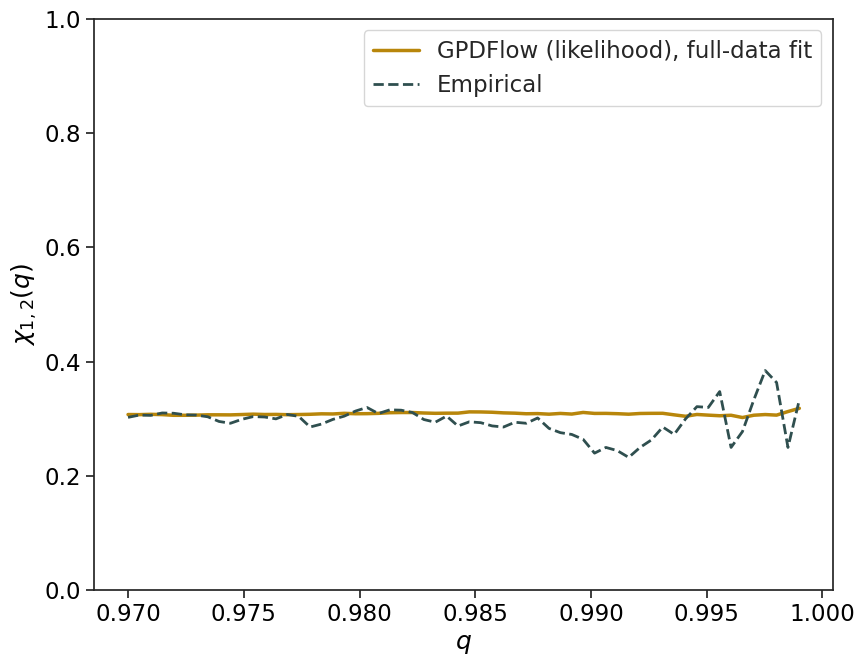

In [19]:
# ---------------------------------------------------------------------------
# Final likelihood GPDFlow: ONE fit on the full exceedance slice, stopped at the
# median of the 5 per-fold CV early-stop epochs.  epochs=EPOCHS_LIK keeps the
# CosineAnnealingLR T_max identical to CV; stop_at_epoch forces the halt.  This
# single model -- not the 5-fold mixture -- is what the threshold-stability
# chi(q) figure should use.
# ---------------------------------------------------------------------------
best_epochs = [h['best_epoch'] for h in cv_like['hist']]
median_epoch = int(np.median(best_epochs))
print('per-fold early-stop epochs:', best_epochs, '-> median:', median_epoch)

final_model, _, _ = cv_utils.fit_gpdflow_likelihood(
    samples, samples, device,
    epochs=EPOCHS_LIK, stop_at_epoch=median_epoch, patience=EPOCHS_LIK + 1,
    **LIK_CFG,
)

final_model.eval()
with torch.no_grad():
    xs, _, _ = final_model.sample(200_000)
samples_final_raw = xs.cpu().numpy() + thres

chi_final_ij = chi_model_ij(samples_final_raw)
print(f'final-model chi_{{{i},{j}}}(q): mean |gap| vs empirical = '
      f'{np.nanmean(np.abs(chi_final_ij - chi_emp_ij)):.4f}')

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(q_grid, chi_final_ij, color='darkgoldenrod', linewidth=2.5,
        label='GPDFlow (likelihood), full-data fit')
ax.plot(q_grid, chi_emp_ij, color='darkslategray', linewidth=2, linestyle='--',
        label='Empirical')
ax.set_xlabel(r'$q$', color='black')
ax.set_ylabel(rf'$\chi_{{{i + 1},{j + 1}}}(q)$', color='black')
ax.set_ylim(0, 1)
ax.tick_params(axis='both', labelcolor='black')
ax.legend()
fig.tight_layout()
# fig.savefig(dir_out + 'Plots/' + 'chi_q_likeli.pdf', bbox_inches='tight')
plt.show()


In [57]:
chi_true = cf.pairwise_chi_from_data(samples_origin, p=THRESHOLD_Q)
p_sim_q = 1.0 - (1.0 - THRESHOLD_Q) / p_cluster    # cluster-conditional level matching q = THRESHOLD_Q


final-model TDE_chi  = 0.0323   RMSE_chi = 0.0403   mean signed bias = +0.0052


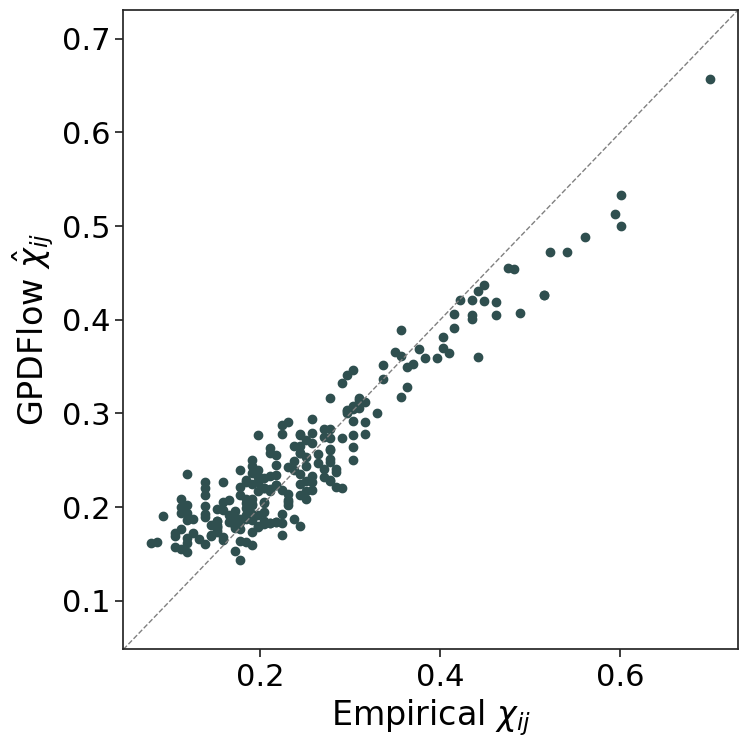

In [58]:
# Scatter plot of empirical vs. GPDFlow-estimated pairwise chi, over the upper
# triangular block (all i<j pairs)
idx = np.triu_indices(dim, k=1)

chi_hat = cf.pairwise_chi_from_data(samples_final_raw, p=p_sim_q)
print(f'final-model TDE_chi  = {cf.tde_chi(chi_hat, chi_true):.4f}   '
      f'RMSE_chi = {cf.rmse_chi(chi_hat[idx], chi_true[idx]):.4f}   '
      f'mean signed bias = {np.mean(chi_hat[idx] - chi_true[idx]):+.4f}')
chi_true_upper = chi_true[idx]
chi_hat_upper = chi_hat[idx]

sns.set(style="ticks", font_scale=2)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(chi_true_upper, chi_hat_upper, color='darkslategray')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Empirical $\chi_{ij}$', color='black')
ax.set_ylabel(r'GPDFlow $\hat{\chi}_{ij}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
plt.show()


fig.tight_layout()
fig.savefig(dir_out + 'Plots/'+'pairwise_chi_likeli.pdf',bbox_inches='tight')
plt.show()

### Simultaneous exceedance probability: empirical vs. GPDFlow (likelihood-based)

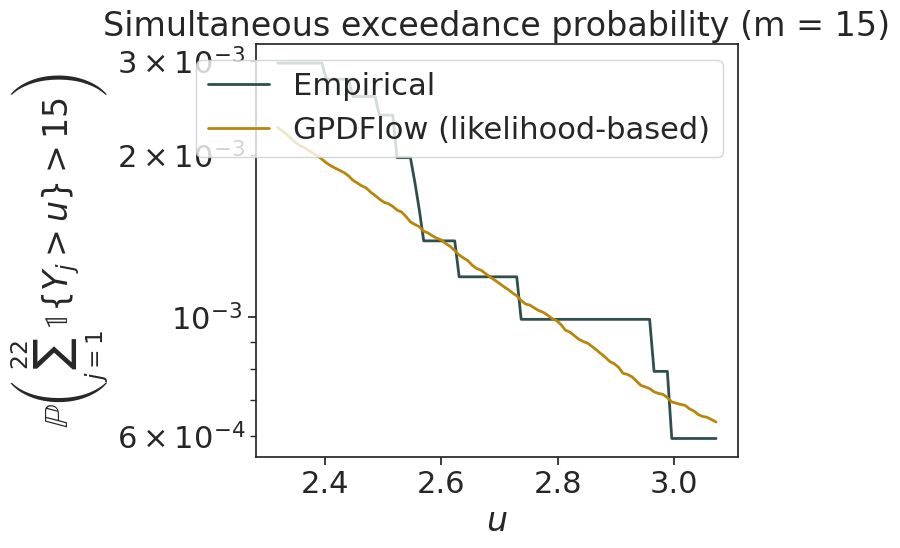

In [21]:
# Simultaneous exceedance probability for the likelihood-based GPDFlow.
# Uses samples_final_raw -- draws from the SINGLE model fitted on the full
# exceedance slice (stopped at the median CV early-stop epoch), NOT the 5-fold
# mixture.  samples_final_raw is already on the raw scale.  The model only
# represents the conditional exceedance-cluster distribution, so its unconditional
# probability
# is recovered via the standard POT/mGPD decomposition
#   P(sum_j 1{Y_j>u} > m) = P(cluster) * P(sum_j 1{Y_j>u} > m | cluster)
# (CLAUDE.md Sec 2.4: Monte Carlo inference for joint exceedance probabilities).
p_cluster = samples.shape[0] / samples_origin.shape[0]

m_fixed = 15
u_grid = cf.common_threshold_grid(samples_origin, n=100)  # 0.97 .. 0.995 quantile band

emp_probs = [cf.simultaneous_exceedance_probability(samples_origin, u, m_fixed) for u in u_grid]
model_probs = [
    p_cluster * cf.simultaneous_exceedance_probability(samples_final_raw, u, m_fixed)
    for u in u_grid
]

plt.figure(figsize=(8, 6))
plt.plot(u_grid, emp_probs, color='darkslategray', linewidth=2, label='Empirical')
plt.plot(u_grid, model_probs, color='darkgoldenrod', linewidth=2, label='GPDFlow (likelihood-based)')
plt.yscale('log')
plt.xlabel(r'$u$')
plt.ylabel(rf'$\mathbb{{P}}\left(\sum_{{j=1}}^{{{dim}}} \mathbb{{1}}\{{Y_j > u\}} > {m_fixed}\right)$')
plt.title(f'Simultaneous exceedance probability (m = {m_fixed})')
plt.legend()
plt.tight_layout()
plt.show()

# Two stage training with likelihood based approach

### Stage 1: standardize margins via univariate GPD fit

In [22]:
# --- Stage 1: fit a univariate GPD to each margin of samples_origin, then
# standardize onto the unit-exponential mGPD scale using the fitted sigma, gamma
# (same construction as the "Standardize margins..." section below, kept
# self-contained here under its own `_2s` suffix) ---
thres_2s = np.quantile(samples_origin, THRESHOLD_Q, axis=0)

uni_sigma_2s = []
uni_gamma_2s = []
for j in range(samples_origin.shape[1]):
    excess_j = samples_origin[samples_origin[:, j] > thres_2s[j], j] - thres_2s[j]
    c, loc, scale = stats.genpareto.fit(excess_j, floc=0)
    uni_gamma_2s.append(c)
    uni_sigma_2s.append(scale)
uni_sigma_2s = np.array(uni_sigma_2s)
uni_gamma_2s = np.array(uni_gamma_2s)

# NOTE: use the independent per-margin scipy GPD fits computed above (matching
# MMD_loss_test.ipynb's In[8]); do NOT overwrite with the joint-likelihood
# GPDFlow margins sigma_hat / gamma_hat -- that made samples_2s differ from that
# notebook's samples_fm.
print('Stage 1 univariate GPD Gamma:', uni_gamma_2s.round(3))
print('Stage 1 univariate GPD Sigma:', uni_sigma_2s.round(3))

# g_std standardization (CLAUDE.md Sec 3.1), applied margin-by-margin using the
# fitted sigma, gamma:
#   Z_j = (1/gamma_j) * log(1 + gamma_j * (X_j - thres_j) / sigma_j),  gamma_j != 0
#   Z_j = (X_j - thres_j) / sigma_j,                                   gamma_j == 0
shifted_2s = samples_origin - thres_2s.reshape(1, -1)

gamma_zero_2s = np.isclose(uni_gamma_2s, 0.0)
gamma_safe_2s = np.where(gamma_zero_2s, 1.0, uni_gamma_2s)

# g_std of a margin *below* its GPD support boundary (1 + gamma*(x-u)/sigma <= 0)
# is genuinely -inf.  The previous code clipped that GPD argument to 1e-6, which
# mapped every non-exceeding margin to Z_j = log(1e-6)/gamma_j ~ -40..-55 -- a
# spurious discontinuous cliff that then dominates the mGPD generator likelihood
# (every family becomes un-fittable, val-NLL ~65-136 vs ~19-25 on the raw scale,
# and the fit collapses toward a near-comonotone generator -> chi ~doubles).
# Instead evaluate Z honestly and floor it on the standardized (unit-exponential)
# scale: a few units below 0 already means "did not exceed" and carries no
# marginal-tail information, so it must not drive the shift integral.
Z_FLOOR = -30.0
inside_2s = 1.0 + gamma_safe_2s * shifted_2s / uni_sigma_2s
inside_ok_2s = inside_2s > 0

samples_origin_std_2s = np.where(
    gamma_zero_2s,
    shifted_2s / uni_sigma_2s,
    np.log(np.where(inside_ok_2s, inside_2s, 1.0)) / gamma_safe_2s,
)
samples_origin_std_2s = np.where((~gamma_zero_2s) & ~inside_ok_2s, -np.inf,
                                 samples_origin_std_2s)
samples_origin_std_2s = np.clip(samples_origin_std_2s, Z_FLOOR, None)


Stage 1 univariate GPD Gamma: [0.248 0.251 0.199 0.157 0.17  0.149 0.133 0.11  0.131 0.264 0.139 0.146
 0.222 0.143 0.118 0.336 0.196 0.048 0.353 0.126 0.22  0.356]
Stage 1 univariate GPD Sigma: [0.521 0.439 0.448 0.587 0.497 0.503 0.51  0.524 0.557 0.52  0.51  0.539
 0.447 0.527 0.546 0.371 0.385 0.587 0.498 0.515 0.518 0.585]


In [23]:
# Re-threshold the standardized data at its own THRESHOLD_Q quantile to obtain the joint
# threshold-exceedance data on the standardized scale (mirrors the `samples`
# construction in the Joint fit section above), then split train/val the same
# way (80/20, seed 1234).
thres_std_2s = 0
cond_2s = np.any(samples_origin_std_2s > thres_std_2s, axis=1)
samples_2s = samples_origin_std_2s[cond_2s, :] - thres_std_2s

seed = 1234
rng = np.random.default_rng(seed)
idx_2s = rng.permutation(len(samples_2s))

split_2s = int(0.8 * len(samples_2s))
train_idx_2s, val_idx_2s = idx_2s[:split_2s], idx_2s[split_2s:]

train_samples_2s = samples_2s[train_idx_2s]
val_samples_2s = samples_2s[val_idx_2s]

# sanity check: non-exceeding margins must land in ~[Z_FLOOR, 0], not at ~-55
print('samples_2s min non-exceeding entry:',
      float(samples_2s[samples_2s < 0].min()))
samples_2s.shape, train_samples_2s.shape, val_samples_2s.shape


samples_2s min non-exceeding entry: -30.0


((1288, 22), (1030, 22), (258, 22))

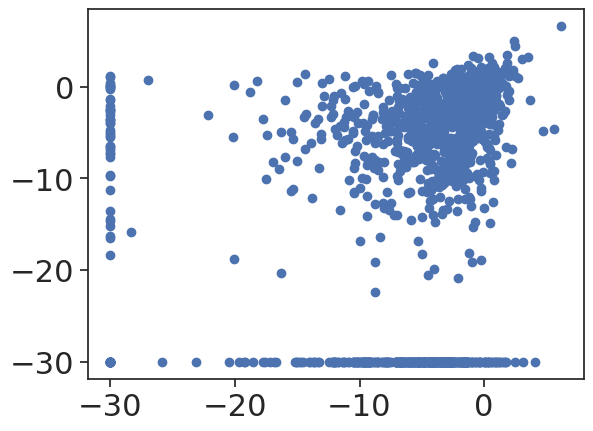

In [24]:
plt.scatter(samples_2s[:,0],samples_2s[:,1] )


### Stage 2: fit GPDFlow with `fix_margin=True`, `use_likelihood=False`

Same architecture and training hyperparameters as the *Joint fit with likelihood based approach* section above, applied to the stage-1 standardized exceedances (`train_samples_2s` / `val_samples_2s`).

> **Note:** the *Stage 1* cell was changed so non-exceeding margins are floored on the standardized scale at `Z_FLOOR` (previously they were clipped to about -55 on the standardized scale, which made every mGPD generator un-fittable). The `model_2s` outputs stored in this section were produced with the old standardization and are **stale until this section is re-run**.


In [25]:
# --- MMD-based (two-stage) GPDFlow, 5-fold cross-validation --------------
# Per fold: refit the Stage-1 univariate GPD on the fold's TRAINING rows only
# (no leakage), standardize + re-threshold train and val on that scale, fit with
# fix_margin=True / use_likelihood=False (unchanged early-stopping rule: patience
# 100 on the validation total loss, 50-epoch warm-up), then map the fold model's
# standardized draws back to the raw scale via that fold's Stage-1 fit.  The 5
# out-of-fold blocks are kept SEPARATE (cv_mmd['samples_simu_2s_folds']); chi
# / omega are formed later as the fold-mean of the per-fold estimates.
# Shared config: used by BOTH the CV below and the final full-data fit.
MMD_CFG = dict(
    warmup_epochs=50, min_delta=1e-3,
    penalty_lambda=1e4, mmd_lambda=15, mmd_samples_per_face=128,
    mmd_censor_c=0, mmd_censor_tau=0.2,
    mmd_indicator_alpha=10, mmd_indicator_rho=5,
    num_layers=4, latent_size_factor=2,
    seed=1234,
)

cv_mmd = run_cv_gpdflow_mmd(
    samples, folds, device, thres,
    epochs=EPOCHS_MMD, samples_multiplier=SIM_MULT,
    patience=100, **MMD_CFG,
)
dim_2s = cv_mmd['dim_2s']

print('per-fold best val loss :', np.round(cv_mmd['best_vals'], 4))
print('per-fold best epoch    :', [h['best_epoch'] for h in cv_mmd['hist']])
print('dropped train rows/fold:', cv_mmd['dropped_rows_train'])
print('dropped val rows/fold  :', cv_mmd['dropped_rows_val'])


[mmd] fold 1/5 (train 1030/1030, val 258/258)
  epoch    1/500 | train=30.3616 | val=29.1377
  epoch   25/500 | train=0.1010 | val=0.5178
  epoch   50/500 | train=0.1025 | val=0.4530
  epoch   75/500 | train=0.0022 | val=0.3589
  epoch  100/500 | train=-0.0680 | val=0.3752
  epoch  125/500 | train=0.0369 | val=0.3470
  epoch  150/500 | train=-0.0586 | val=0.3134
  epoch  175/500 | train=-0.0625 | val=0.2695
  epoch  200/500 | train=-0.0591 | val=0.2537
  epoch  225/500 | train=-0.0129 | val=0.3354
  epoch  250/500 | train=-0.0297 | val=0.2921
  epoch  275/500 | train=0.0394 | val=0.2896
  epoch  300/500 | train=-0.0247 | val=0.3357
  epoch  325/500 | train=-0.1005 | val=0.3204
  epoch  350/500 | train=-0.0252 | val=0.2949
  epoch  375/500 | train=-0.0463 | val=0.2893
  epoch  400/500 | train=-0.0183 | val=0.3239
  epoch  425/500 | train=-0.0889 | val=0.3288
  early stopping at epoch 442 (best val loss @ 342).
[mmd] fold 2/5 (train 1030/1030, val 258/258)
  epoch    1/500 | train=31.390

In [26]:
# Pairwise chi: empirical truth (samples_origin, q = THRESHOLD_Q) vs the mean over the 5
# CV folds of each fold model's pairwise_chi_from_data at p_sim_q.  Rank-based;
# folds are NOT pooled; computed here from cv_mmd['samples_simu_2s_folds'].
chi_true_2s = cf.pairwise_chi_from_data(samples_origin, p=THRESHOLD_Q)
chi_hat_2s = cv_pairwise_chi(cv_mmd['samples_simu_2s_folds'], p_sim_q)
print('p_sim_q =', round(p_sim_q, 4), '  TDE_chi =', round(cf.tde_chi(chi_hat_2s, chi_true_2s), 4))


p_sim_q = 0.8824   TDE_chi = 0.0227


per-fold early-stop epochs [MMD]: [342, 194, 214, 189, 164] -> median: 194
  epoch    1/500 | train=30.3596 | val=26.7822


  epoch   25/500 | train=0.1927 | val=0.3219
  epoch   50/500 | train=0.1272 | val=0.2170
  epoch   75/500 | train=-0.0161 | val=0.1730
  epoch  100/500 | train=-0.0210 | val=0.1606
  epoch  125/500 | train=0.0019 | val=0.1594
  epoch  150/500 | train=0.0190 | val=0.1776
  epoch  175/500 | train=-0.0124 | val=0.1356
  stopping at fixed epoch 194 (stop_at_epoch).
final-model chi_{0,21}(q) [MMD]: mean |gap| vs empirical = 0.0707


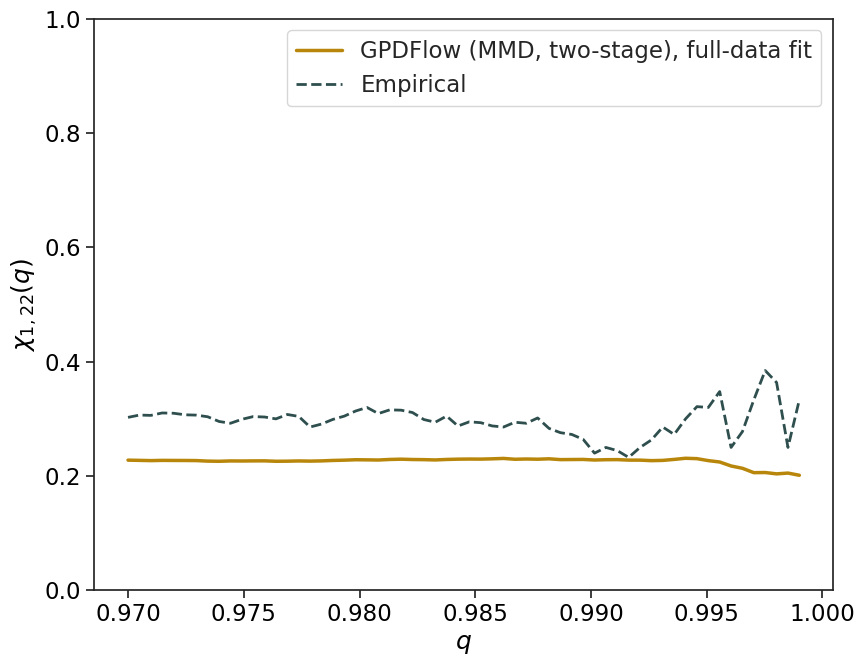

In [82]:
# Final two-stage MMD GPDFlow: one fit on the full standardized exceedance slice
# `samples_2s` (Stage-1 params uni_sigma_2s / uni_gamma_2s from the cell above),
# stopped at the median of the 5 per-fold CV early-stop epochs.
best_epochs_2s = [h['best_epoch'] for h in cv_mmd['hist']]
median_epoch_2s = int(np.median(best_epochs_2s))
print('per-fold early-stop epochs [MMD]:', best_epochs_2s, '-> median:', median_epoch_2s)

final_model_2s, _, _ = cv_utils.fit_gpdflow_mmd(
    samples_2s, samples_2s, device,
    epochs=EPOCHS_MMD, stop_at_epoch=median_epoch_2s, patience=EPOCHS_MMD + 1,
    **MMD_CFG,
)

final_model_2s.eval()
with torch.no_grad():
    _, ys, _ = final_model_2s.sample(200_000)
samples_final_2s_raw = cv_utils._gpd_unstandardize(
    ys.cpu().numpy(), np.asarray(uni_sigma_2s), np.asarray(uni_gamma_2s), thres_2s,
)

chi_final_ij_2s = chi_model_ij(samples_final_2s_raw)
print(f'final-model chi_{{{i},{j}}}(q) [MMD]: mean |gap| vs empirical = '
      f'{np.nanmean(np.abs(chi_final_ij_2s - chi_emp_ij)):.4f}')

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(q_grid, chi_final_ij_2s, color='darkgoldenrod', linewidth=2.5,
        label='GPDFlow (MMD, two-stage), full-data fit')
ax.plot(q_grid, chi_emp_ij, color='darkslategray', linewidth=2, linestyle='--',
        label='Empirical')
ax.set_xlabel(r'$q$', color='black')
ax.set_ylabel(rf'$\chi_{{{i + 1},{j + 1}}}(q)$', color='black')
ax.set_ylim(0, 1)
ax.tick_params(axis='both', labelcolor='black')
ax.legend()
fig.tight_layout()
fig.savefig(dir_out + 'Plots/' + 'chi_q_MMD.pdf', bbox_inches='tight')
plt.show()


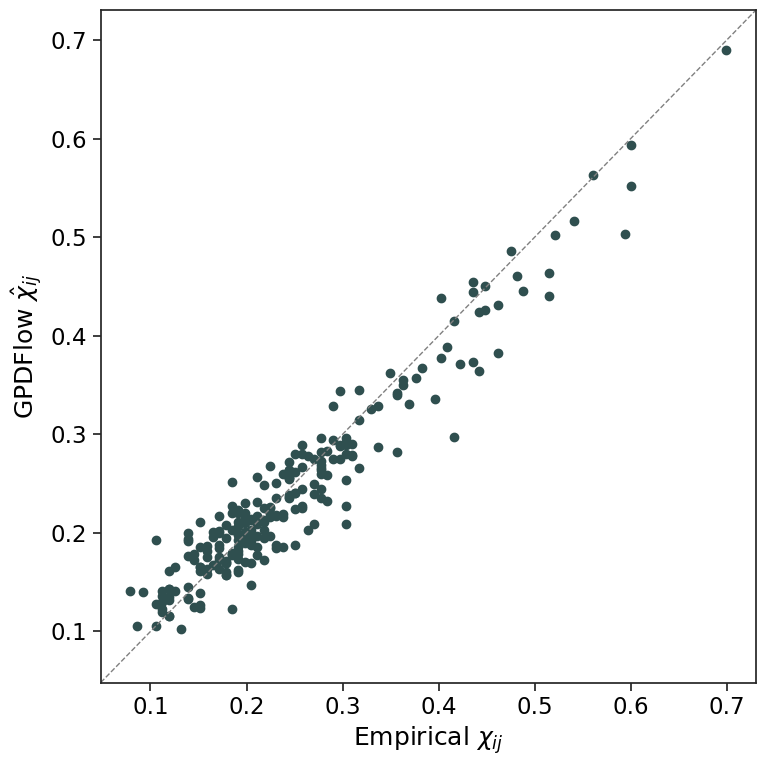

In [28]:
# Scatter plot of empirical vs. GPDFlow-estimated pairwise chi, over the upper
# triangular block (all i<j pairs)


idx_pairs_2s = np.triu_indices(dim_2s, k=1)
chi_hat_2s = cf.pairwise_chi_from_data(samples_final_2s_raw, p=p_sim_q)
chi_true_upper_2s = chi_true_2s[idx_pairs_2s]
chi_hat_upper_2s = chi_hat_2s[idx_pairs_2s]

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(chi_true_upper_2s, chi_hat_upper_2s, color='darkslategray')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Empirical $\chi_{ij}$', color='black')
ax.set_ylabel(r'GPDFlow $\hat{\chi}_{ij}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
plt.show()

fig.tight_layout()
fig.savefig(dir_out + 'Plots/'+'pairwise_chi_MMD.pdf',bbox_inches='tight')
plt.show()


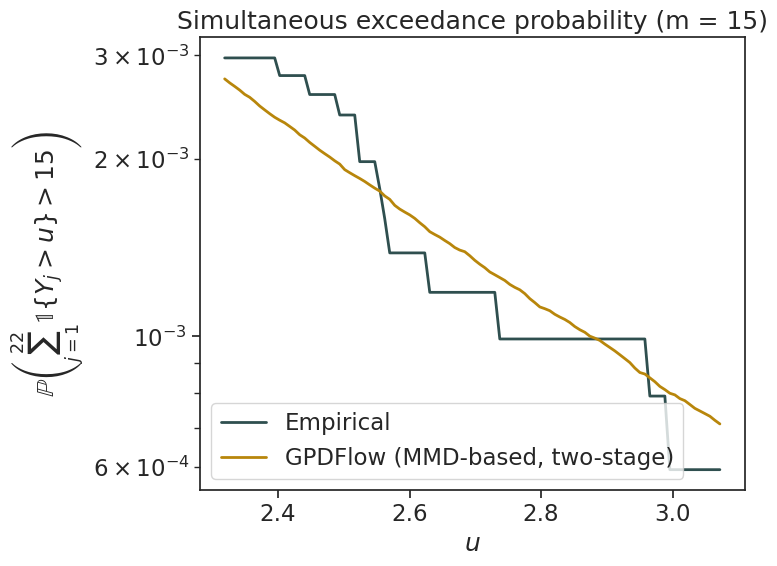

In [29]:
# Simultaneous exceedance probability for the two-stage MMD-based GPDFlow CV fit.
# samples_final_2s_raw: draws from the SINGLE two-stage model fitted on the full
# standardized exceedance slice (stopped at the median CV early-stop epoch),
# inverted through the full-data Stage-1 GPD fit.  model_2s only
# represents the conditional exceedance-cluster distribution, so its
# unconditional probability is recovered via P(cluster) * P(... | cluster)
# (CLAUDE.md Sec 2.4). p_cluster_2s uses the full-data standardized slice.
p_cluster_2s = samples.shape[0] / samples_origin.shape[0]

m_fixed = 15
u_grid = cf.common_threshold_grid(samples_origin, n=100)  # 0.97 .. 0.995 quantile band

emp_probs = [cf.simultaneous_exceedance_probability(samples_origin, u, m_fixed) for u in u_grid]
model_probs_2s = [
    p_cluster_2s * cf.simultaneous_exceedance_probability(samples_final_2s_raw, u, m_fixed)
    for u in u_grid
]

plt.figure(figsize=(8, 6))
plt.plot(u_grid, emp_probs, color='darkslategray', linewidth=2, label='Empirical')
plt.plot(u_grid, model_probs_2s, color='darkgoldenrod', linewidth=2, label='GPDFlow (MMD-based, two-stage)')
plt.yscale('log')
plt.xlabel(r'$u$')
plt.ylabel(rf'$\mathbb{{P}}\left(\sum_{{j=1}}^{{{dim_2s}}} \mathbb{{1}}\{{Y_j > u\}} > {m_fixed}\right)$')
plt.title(f'Simultaneous exceedance probability (m = {m_fixed})')
plt.legend()
plt.tight_layout()
plt.show()

### Model Comparison

#### Normalizing Flows

**Baseline: probit-copula RealNVP.** A generic deep density estimator to contrast with GPDFlow, fit on the *same* threshold-exceedance slice.

Naively PIT-ing each margin to Uniform(0,1) or unit-Exponential and fitting an affine RealNVP leaves a hard support boundary (the box edge, or 0) exactly where the exceedance data is densest; a Gaussian-base flow has full support on $\mathbb{R}^d$ and leaks mass past that edge. Instead we compose the GPD marginal transform with a probit step, $W_j = \Phi^{-1}(F_j(X_j))$, so every margin lands on the whole real line and the flow only has to learn the *dependence* — matching GPDFlow's design of keeping the flow away from the marginal tails.

Pipeline:
1. Per-margin hybrid CDF $F_j$: empirical body ($x\le 0$) + univariate GPD tail ($x>0$).
2. $W = \Phi^{-1}(F(X))$; fit an unconditional RealNVP on $\mathbb{R}^{22}$ by maximum likelihood, with the checkpoint early-stopped on the held-out NLL after a short warm-up.
3. Sample $W^\* \to \Phi \to F^{-1} \to X^\*$; compare pairwise $\chi$/$\omega$ and the simultaneous-exceedance-probability curve against the empirical estimate and the two GPDFlow fits.

**Caveat.** This copula-flow has no asymptotic-dependence or threshold-stability guarantee: its $\chi(q)$ may decay toward 0 and its exceedance curve is unreliable above $q\approx 0.995$ (shaded in the plot). Quantitative error metrics are restricted to the data-supported range.

W_train: finite = True | per-margin mean ~ 0.001 | per-margin std ~ 0.997


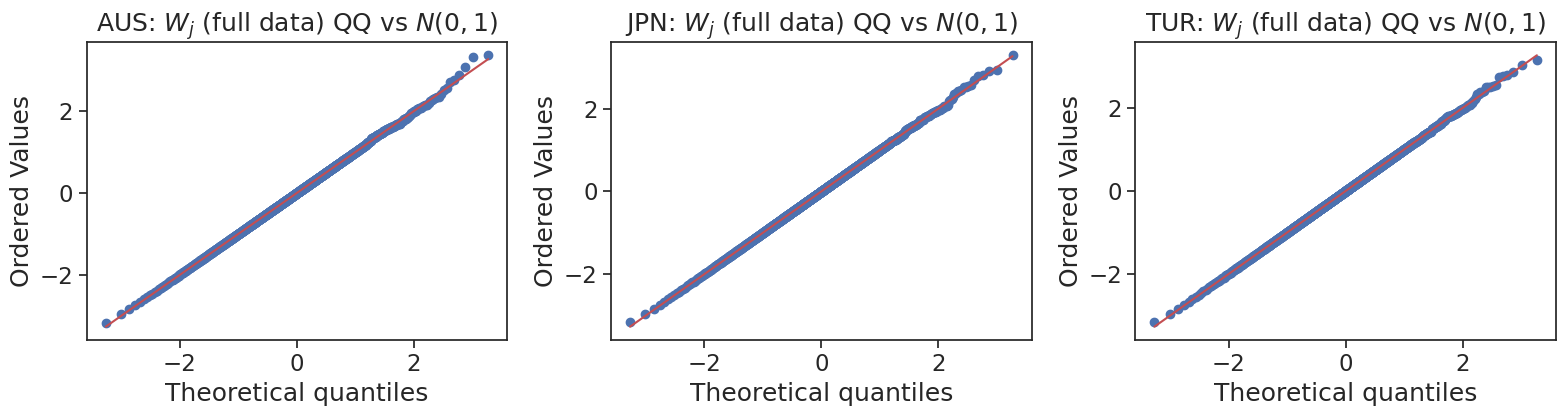

In [30]:
# # ============================================================================
# # Baseline: probit-copula RealNVP  --  full-data marginal model for diagnostics
# # ============================================================================
# # The cross-validated baseline (next cell) refits this hybrid marginal model
# # per fold inside cv_utils. Here it is fit ONCE on the full slice `samples` to
# # provide a single W_train / to_gaussian / from_gaussian for the illustrative
# # QQ and dependence-tracing plots below. Margins: empirical body for x<=0, a
# # univariate GPD tail for x>0; the probit map W_j = Phi^{-1}(F_j(X_j)) sends
# # every margin onto the whole real line.
n_slice = samples.shape[0]
to_gaussian, from_gaussian, marginal_cdf, marginal_ppf = build_probit_copula(samples, dim)

W_train = to_gaussian(samples)
W_val = to_gaussian(val_samples)
print('W_train: finite =', np.isfinite(W_train).all(),
      '| per-margin mean ~', np.round(W_train.mean(0).mean(), 3),
      '| per-margin std ~', np.round(W_train.std(0).mean(), 3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, j in zip(axes, [0, 9, 21]):
    stats.probplot(W_train[:, j], dist='norm', plot=ax)
    ax.set_title(f'{ctry_codes[j]}: $W_j$ (full data) QQ vs $N(0,1)$')
plt.tight_layout()
plt.show()


In [83]:
# --- Probit-copula RealNVP baseline, 5-fold cross-validation --------------
# Per fold: refit the hybrid marginal model on the fold's training rows, train
# the unconditional RealNVP (4 coupling layers, hidden 2d, input jitter) by
# maximum likelihood on the pseudo-Gaussian train data, and early-stop on the
# held-out NLL after a 20-epoch warm-up. Then map SIM_MULT * |fold| finite
# draws back to the raw scale.  The 5 out-of-fold blocks are kept SEPARATE
# (cv_bl['samples_simu_bl_folds']) -- as with the GPDFlow drivers, a pool of
# draws from 5 separately fitted flows is a mixture; chi / omega are formed
# below as the fold-mean of the per-fold estimates.
# Shared config: used by BOTH the CV below and the final full-data fit
# (RealNVP arch = build_baseline_flow defaults: num_layers=4, hidden_mult=2).
BL_CFG = dict(warmup=20, seed=0,  num_layers = 6, hidden_mult = 4)

cv_bl = run_cv_flow_baseline(
    samples, folds, device, thres,
    epochs=EPOCHS_BL, samples_multiplier=SIM_MULT,
    patience=40, **BL_CFG,
)
flow_baseline = cv_bl['models'][-1]              # last fold's flow, for the diagnostics below
print('per-fold best val NLL:', np.round(cv_bl['best_vals'], 4))
print('per-fold best epoch  :', [h['best_epoch'] for h in cv_bl['hist']])


[baseline] fold 1/5 (train 1030, val 258)
  epoch    1/400 | train_nll=31.222 | val_nll=30.244
  epoch   25/400 | train_nll=25.159 | val_nll=27.850
  epoch   50/400 | train_nll=23.814 | val_nll=28.790
  early stopping at epoch 66 (best val NLL @ 26).
[baseline] fold 2/5 (train 1030, val 258)
  epoch    1/400 | train_nll=31.319 | val_nll=30.068
  epoch   25/400 | train_nll=25.329 | val_nll=27.051
  epoch   50/400 | train_nll=23.882 | val_nll=28.410
  early stopping at epoch 63 (best val NLL @ 23).
[baseline] fold 3/5 (train 1030, val 258)
  epoch    1/400 | train_nll=31.349 | val_nll=30.545
  epoch   25/400 | train_nll=25.140 | val_nll=27.768
  epoch   50/400 | train_nll=23.826 | val_nll=28.816
  early stopping at epoch 64 (best val NLL @ 24).
[baseline] fold 4/5 (train 1031, val 257)
  epoch    1/400 | train_nll=31.277 | val_nll=29.998
  epoch   25/400 | train_nll=25.106 | val_nll=27.699
  epoch   50/400 | train_nll=23.794 | val_nll=28.657
  early stopping at epoch 62 (best val NLL @ 2

In [84]:
# ---------------------------------------------------------------------------
# Final probit-copula RealNVP baseline: ONE fit on the full exceedance slice,
# stopped at the median of the 5 per-fold CV early-stop epochs (same procedure
# as the likelihood / MMD GPDFlow final fits).  to_gaussian / from_gaussian are
# already fit on the full slice `samples` in the cell above.
# ---------------------------------------------------------------------------
best_epochs_bl = [h['best_epoch'] for h in cv_bl['hist']]
median_epoch_bl = int(np.median(best_epochs_bl))
print('per-fold early-stop epochs [baseline]:', best_epochs_bl,
      '-> median:', median_epoch_bl)

W_full_bl = to_gaussian(samples)
flow_bl_final, _, _ = cv_utils.fit_flow_baseline(
    W_full_bl, W_full_bl, device,
    epochs=EPOCHS_BL, stop_at_epoch=median_epoch_bl, patience=EPOCHS_BL + 1,
    **BL_CFG,
)

flow_bl_final.eval()
_collected, _have = [], 0
for _ in range(50):
    if _have >= 200_000:
        break
    with torch.no_grad():
        _Ws, _ = flow_bl_final.sample(max(2 * (200_000 - _have), 4096))
    _Ws = _Ws.cpu().numpy()
    _Ws = _Ws[np.isfinite(_Ws).all(axis=1)]
    _collected.append(_Ws)
    _have += _Ws.shape[0]
samples_final_bl_raw = from_gaussian(np.vstack(_collected)[:200_000]) + thres
print('samples_final_bl_raw:', samples_final_bl_raw.shape,
      '| finite:', bool(np.isfinite(samples_final_bl_raw).all()))


per-fold early-stop epochs [baseline]: [26, 23, 24, 22, 25] -> median: 24


  epoch    1/400 | train_nll=31.051 | val_nll=29.692
  stopping at fixed epoch 24 (stop_at_epoch).
samples_final_bl_raw: (200000, 22) | finite: True


sampled W* : mean over margins = -0.021 | std over margins = 0.943
corr(train vs sampled Spearman rho, off-diagonal) = 0.978


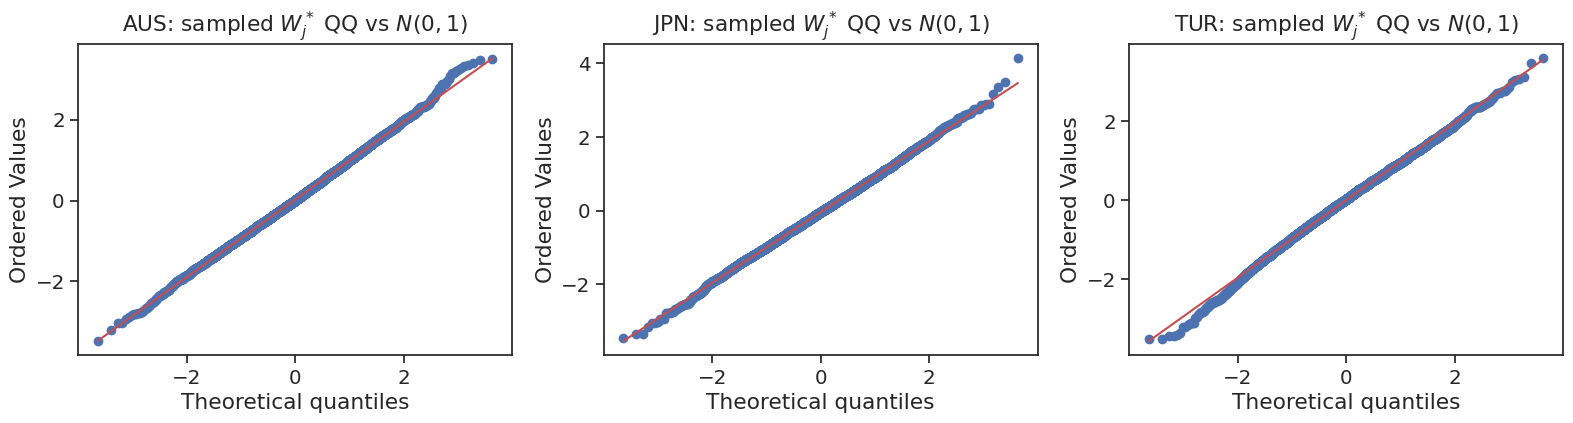

In [85]:
# --- Sanity checks on the fitted baseline flow -----------------------------
from scipy.stats import spearmanr

flow_baseline.eval()
with torch.no_grad():
    W_star, _ = flow_baseline.sample(50000)
W_star = W_star.cpu().numpy()
W_star = W_star[np.isfinite(W_star).all(axis=1)]

print('sampled W* : mean over margins =', W_star.mean(0).mean().round(3),
      '| std over margins =', W_star.std(0).mean().round(3))

# Dependence sanity: rank correlation of sampled vs training pseudo-Gaussian data
rho_tr = spearmanr(W_train).correlation
rho_st = spearmanr(W_star).correlation
iu = np.triu_indices(dim, k=1)
print('corr(train vs sampled Spearman rho, off-diagonal) =',
      np.corrcoef(rho_tr[iu], rho_st[iu])[0, 1].round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, j in zip(axes, [0, 9, 21]):
    stats.probplot(W_star[:5000, j], dist='norm', plot=ax)
    ax.set_title(f'{ctry_codes[j]}: sampled $W^*_j$ QQ vs $N(0,1)$')
plt.tight_layout()
plt.show()


Probit-copula RealNVP   tde_chi   (full): 0.039269536728257684
Probit-copula RealNVP   tde_omega (full): 0.035660470988129175


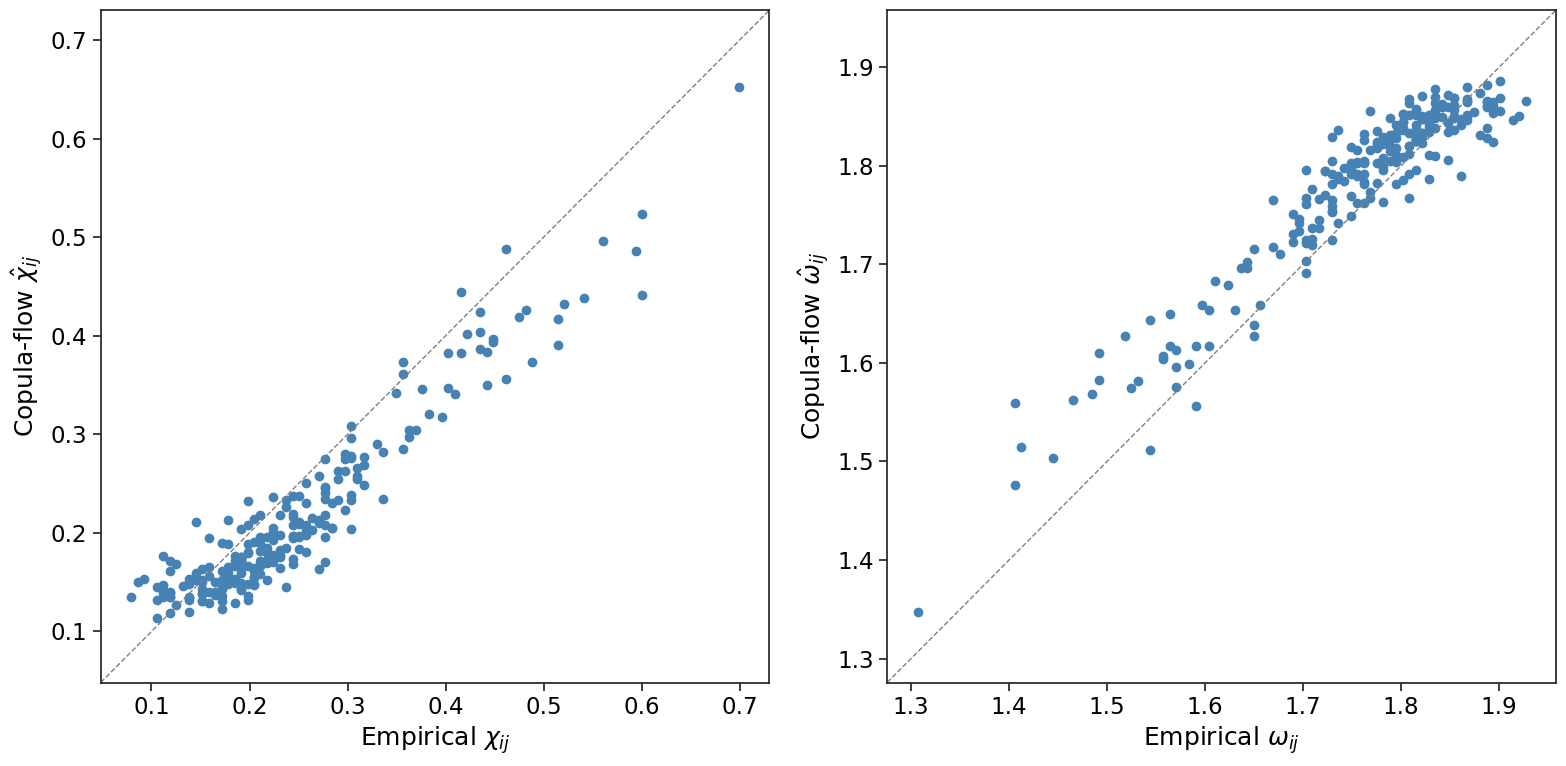

In [86]:
# --- Cross-validated baseline-flow samples: pairwise chi / omega -----------
# Same construction as the GPDFlow cells: the 5 out-of-fold draw blocks are kept
# SEPARATE (cv_bl['samples_simu_bl_folds']); chi / omega are the fold-mean of
# each fold model's rank-based pairwise_chi_from_data, evaluated at the matching
# cluster-conditional level p_sim_q = 1 - (1 - THRESHOLD_Q) / p_cluster.  The
# full-data-fit estimate (samples_final_bl_raw) is reported alongside.  Both
# estimators are rank-based, hence invariant to the monotone per-margin transforms.
chi_true_bl = cf.pairwise_chi_from_data(samples_origin, p=THRESHOLD_Q)
omega_true_bl = cf.pairwise_omega_from_data(samples_origin, p=THRESHOLD_Q)

# chi_hat_bl = cv_pairwise_chi(cv_bl['samples_simu_bl_folds'], p_sim_q)
# omega_hat_bl = cv_pairwise_omega(cv_bl['samples_simu_bl_folds'], p_sim_q)
chi_hat_bl_final = cf.pairwise_chi_from_data(samples_final_bl_raw, p=p_sim_q)
omega_hat_bl_final = cf.pairwise_omega_from_data(samples_final_bl_raw, p=p_sim_q)

# print('Probit-copula RealNVP   tde_chi   (CV):  ', cf.tde_chi(chi_hat_bl, chi_true_bl))
# print('Probit-copula RealNVP   tde_omega (CV):  ', cf.tde_chi(omega_hat_bl, omega_true_bl))
print('Probit-copula RealNVP   tde_chi   (full):', cf.tde_chi(chi_hat_bl_final, chi_true_bl))
print('Probit-copula RealNVP   tde_omega (full):', cf.tde_chi(omega_hat_bl_final, omega_true_bl))

iu = np.triu_indices(dim, k=1)
sns.set(style="ticks", font_scale=1.5)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, true_m, hat_m, sym in [
    (axes[0], chi_true_bl, chi_hat_bl_final, r'\chi'),
    (axes[1], omega_true_bl, omega_hat_bl_final, r'\omega'),
]:
    ax.scatter(true_m[iu], hat_m[iu], color='steelblue')
    lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
    ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(rf'Empirical ${sym}_{{ij}}$', color='black')
    ax.set_ylabel(rf'Copula-flow $\hat{{{sym}}}_{{ij}}$', color='black')
    ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
plt.show()


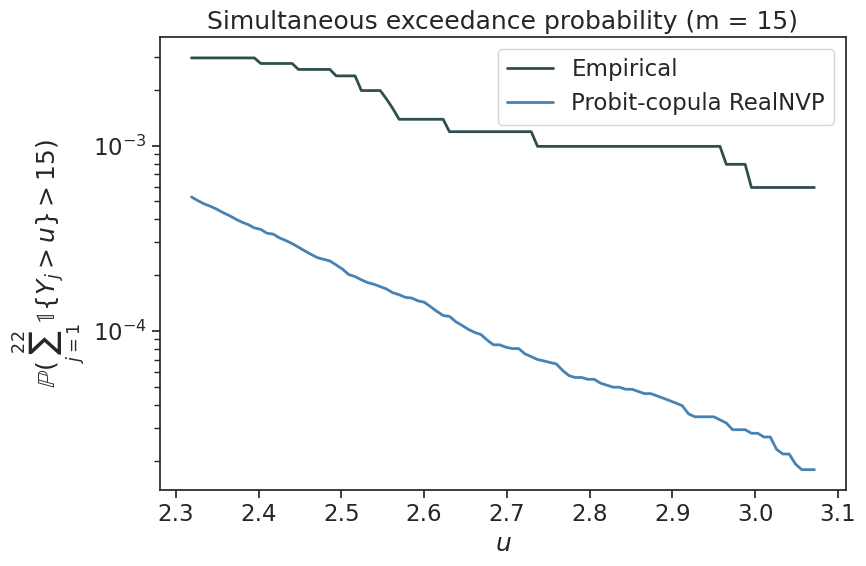

model                             LJPE   RMSLE_p
Probit-copula RealNVP           2.6626    2.7047


In [87]:
# --- Simultaneous exceedance probability: baseline normalizing flow vs empirical ---
# Same construction as the GPDFlow cells: the copula flow represents the
# conditional exceedance-cluster distribution, so its unconditional probability
# is P(cluster) * P(event | cluster) (CLAUDE.md Sec 2.4). Only the normalizing
# flow model is shown here; the full cross-model overlay is in the final cell.
p_cluster_bl = n_slice / samples_origin.shape[0]

m_fixed = 15
u_grid = cf.common_threshold_grid(samples_origin, n=100)  # 0.97 .. 0.995 quantile band

emp_probs_cmp = np.array(
    [cf.simultaneous_exceedance_probability(samples_origin, u, m_fixed) for u in u_grid]
)
flow_bl_probs = np.array([
    p_cluster_bl
    * cf.simultaneous_exceedance_probability(samples_final_bl_raw, u, m_fixed)
    for u in u_grid
])

plt.figure(figsize=(9, 6))
plt.plot(u_grid, emp_probs_cmp, color='darkslategray', lw=2, label='Empirical')
plt.plot(u_grid, flow_bl_probs, color='steelblue', lw=2, label='Probit-copula RealNVP')
plt.yscale('log')
plt.xlabel(r'$u$')
plt.ylabel(rf'$\mathbb{{P}}(\sum_{{j=1}}^{{{dim}}}\mathbb{{1}}\{{Y_j>u\}} > {m_fixed})$')
plt.title(f'Simultaneous exceedance probability (m = {m_fixed})')
plt.legend()
plt.tight_layout()
plt.savefig(dir_out + 'Plots/simultaneous_exceedance_comparison.pdf', bbox_inches='tight')
plt.show()

# --- Quantitative exceedance-probability error over the full u-grid, which is
#     data-supported end to end (a common threshold stays between every margin's
#     0.97 and 0.995 empirical quantile across the whole grid).
def _err(probs):
    p_hat = np.asarray(probs)
    p_true = emp_probs_cmp
    ok = p_true > 0
    return cf.ljpe(p_hat[ok], p_true[ok]), cf.rmsle_p(p_hat[ok], p_true[ok])


rows = [('Probit-copula RealNVP', *_err(flow_bl_probs))]

print(f'{"model":28s}  {"LJPE":>8s}  {"RMSLE_p":>8s}')
for name, a, b in rows:
    print(f'{name:28s}  {a:8.4f}  {b:8.4f}')

### Traditional mGPD comparison

#### Parametric mGPD: T-representation with a fixed generator family

The GPDFlow fits above replace the mGPD generator by a normalizing flow. The
classical alternative (Kiriliouk-Rootzen-Segers-Wadsworth) keeps the generator
**parametric**: write the standardized spectral vector as $S = T - \max(T)$ and
give $T$ a fixed distributional form. The standardized-mGPD density is then

$$h(z) = \mathbb{1}\{\max(z) > 0\}\, e^{-\max(z)} \int_{-\infty}^{\infty} f_T(z + s\,\mathbf{1})\, ds ,$$

and the observational-scale density multiplies this by the marginal Jacobian
$\prod_j (\sigma_j + \gamma_j x_j)^{-1}$ with $z = g_{\text{std}}(x;\sigma,\gamma)$
(CLAUDE.md 3.4). The 1-D integral over the common shift $s$ is evaluated by the
trapezoidal rule with a log-sum-exp stabiliser, exactly as in
`GPDFlow.py::T_mGPD_NF`.

Five generator families are fit: independent **Gumbel**, independent **reverse
Gumbel**, independent **reverse exponential**, independent **log-gamma**, and a
**multivariate Gaussian** generator. All generator parameters *and* the marginal
$(\sigma,\gamma)$ are learnable and estimated by stochastic-gradient maximum
likelihood on the same seed-1234 training split used elsewhere in the notebook;
one generator location per family is pinned to $0$ because $S=T-\max(T)$ is
shift-invariant. The family with the smallest **AIC** (training-set
log-likelihood, penalised by the number of identified free parameters) is carried
forward and evaluated on pairwise $\chi$, pairwise $\omega$ and the
simultaneous-exceedance probability, matching the GPDFlow diagnostics.

In [36]:
# ============================================================================
# Parametric mGPD  --  T-representation with a fixed parametric generator
# ============================================================================
# Same mGPD skeleton as GPDFlow, but the generator T is one of five parametric
# families instead of a normalizing flow.  The ParametricMGPD class and its
# fitting / model-selection helpers now live in parametric_mGPD.py, with the
# public + internal API aligned to GPDFlow.py::T_mGPD_NF (log_integral_f_T,
# log_prob_T_mGPD_std, loss_components keys, sample() signature, ...).  See that
# module docstring for the standardized-mGPD log-density and the trapezoid +
# log-sum-exp shift integral.
import importlib
import parametric_mGPD
importlib.reload(parametric_mGPD)  # pick up edits without a kernel restart
from parametric_mGPD import (
    ParametricMGPD,
    GENERATORS,
    fit_parametric_mgpd,
    support_mask,
)


In [37]:
# --- Fit all five generator families on the training split (seed 1234) --------
_param_train, _param_val = train_samples, val_samples
dim = _param_train.shape[1]

param_models, param_val_nll, param_hist = {}, {}, {}
for _gen in GENERATORS:
    print(f'Fitting parametric mGPD generator: {_gen}')
    _m, _v, _h = fit_parametric_mgpd(_gen, _param_train, _param_val, device,
                                     epochs=300, batch_size=256, seed=1234)
    param_models[_gen], param_val_nll[_gen], param_hist[_gen] = _m, _v, _h
    print(f'  -> best validation NLL: {_v:.4f}\n')

Fitting parametric mGPD generator: gumbel


  [gumbel    ] ep   0  batch loss     91.241   val NLL    42.674   (best    42.674)
  [gumbel    ] ep  50  batch loss     22.484   val NLL    22.329   (best    22.329)
  [gumbel    ] ep 100  batch loss     23.179   val NLL    22.179   (best    22.173)
  [gumbel    ] ep 150  batch loss     22.117   val NLL    22.142   (best    22.118)
  [gumbel    ] ep 200  batch loss     22.723   val NLL    22.114   (best    22.098)
  [gumbel    ] ep 235  batch loss     30.748   val NLL    22.106   (best    22.098)
  -> best validation NLL: 22.0985

Fitting parametric mGPD generator: rev_gumbel
  [rev_gumbel] ep   0  batch loss     82.540   val NLL    41.242   (best    41.242)
  [rev_gumbel] ep  50  batch loss     23.977   val NLL    23.007   (best    21.817)
  [rev_gumbel] ep  65  batch loss     19.745   val NLL    23.508   (best    21.817)
  -> best validation NLL: 21.8168

Fitting parametric mGPD generator: rev_exp
  [rev_exp   ] ep   0  batch loss     83.860   val NLL    43.311   (best    43.311)
 

In [38]:
# --- Model selection by AIC (training-set log-likelihood) --------------------
# AIC = 2k - 2*loglik, loglik summed over the training rows that lie inside every
# family's fitted GPD marginal support (so all families are scored on the same
# rows).  A generator that cannot represent a row's standardized spectrum
# (notably the reverse-exponential generator, hard support t <= mu) assigns it
# near-zero density; each such row's log-density is floored at FLOOR = -1000 so a
# handful of pathological rows cannot send the sum to -inf, but the row still
# counts fully against that family's AIC.  `n_floored` reports how many rows were
# floored -- a large value flags a family that genuinely does not fit this data.
import pandas as pd

FLOOR = -1000.0
_tr = torch.tensor(np.asarray(_param_train), dtype=torch.float32, device=device)
_va = torch.tensor(np.asarray(_param_val), dtype=torch.float32, device=device)

_lp_tr, _sup_tr, _lp_va, _sup_va = {}, {}, {}, {}
for g, m in param_models.items():
    with torch.no_grad():
        _lp_tr[g] = m.log_prob(_tr)
        _lp_va[g] = m.log_prob(_va)
    _sup_tr[g] = support_mask(m, _tr)
    _sup_va[g] = support_mask(m, _va)

_common = torch.ones(_tr.shape[0], dtype=torch.bool, device=device)
for g in GENERATORS:
    _common &= _sup_tr[g]
print(f'training rows inside the common GPD marginal support of all five '
      f'families: {int(_common.sum())} / {_tr.shape[0]}\n')

_rows = []
for g in GENERATORS:
    lp = _lp_tr[g][_common]
    n_floored = int((lp < FLOOR).sum())
    loglik = float(lp.clamp(min=FLOOR).sum())
    k = param_models[g].n_params()
    vlp = _lp_va[g][_sup_va[g]].clamp(min=FLOOR)
    vnll = float(-vlp.mean()) if vlp.numel() else float('nan')
    _rows.append({'generator': g, 'k': k, 'loglik': loglik,
                  'AIC': 2 * k - 2 * loglik, 'val_nll': vnll,
                  'n_floored': n_floored})

aic_table = pd.DataFrame(_rows).sort_values('AIC').reset_index(drop=True)
aic_table['dAIC'] = aic_table['AIC'] - aic_table['AIC'].min()
aic_table = aic_table[['generator', 'k', 'loglik', 'AIC', 'dAIC',
                       'val_nll', 'n_floored']]
print(aic_table.to_string(index=False))

best_family = aic_table.loc[0, 'generator']
best_model = param_models[best_family]
print(f'\nAIC-best parametric generator: {best_family}')


training rows inside the common GPD marginal support of all five families: 878 / 1030

 generator   k        loglik           AIC          dAIC   val_nll  n_floored
  gaussian 318 -17096.585938  34829.171875      0.000000 19.465622          0
rev_gumbel  87 -19652.812500  39479.625000   4650.453125 21.886288          0
    gumbel  87 -19930.878906  40035.757812   5206.585938 22.142460          0
 log_gamma  87 -19967.417969  40108.835938   5279.664062 22.162905          0
   rev_exp  87 -68866.257812 137906.515625 103077.343750 85.534119         47

AIC-best parametric generator: gaussian


In [39]:
# --- Parametric mGPD, 5-fold cross-validation (AIC-best family) ------------
# Same recipe as the GPDFlow drivers: per fold train on the other 4 folds
# (margins learned jointly), early-stop on the held-out fold, keep the 5
# out-of-fold draw blocks SEPARATE.  chi is the fold-mean of the per-fold
# pairwise_chi_from_data at the cluster-conditional level p_sim_q.
# Shared config: used by BOTH the CV below and the final full-data fit.
PAR_CFG = dict(generator=best_family, seed=1234)

cv_par = run_cv_parametric_mgpd(
    samples, folds, device, thres,
    epochs=EPOCHS_PAR, samples_multiplier=SIM_MULT, **PAR_CFG,
)
print('per-fold best val NLL [par]:', np.round(cv_par['best_vals'], 4))
print('per-fold best epoch   [par]:', [h['best_epoch'] for h in cv_par['hist']])

chi_true_par = cf.pairwise_chi_from_data(samples_origin, p=THRESHOLD_Q)
chi_hat_par_cv = cv_pairwise_chi(cv_par['samples_simu_par_folds'], p_sim_q)
print('Traditional mGPD   tde_chi (CV):',
      round(cf.tde_chi(chi_hat_par_cv, chi_true_par), 4))


[parametric:gaussian] fold 1/5 (train 1030, val 258)


  [gaussian  ] ep   0  batch loss    748.301   val NLL    45.620   (best    45.620)
  [gaussian  ] ep  50  batch loss     16.514   val NLL    19.213   (best    19.213)
  [gaussian  ] ep 100  batch loss     21.092   val NLL    19.212   (best    19.180)
  [gaussian  ] ep 150  batch loss     15.166   val NLL    19.195   (best    19.179)
  [gaussian  ] ep 154  batch loss     17.426   val NLL    19.207   (best    19.179)
[parametric:gaussian] fold 2/5 (train 1030, val 258)
  [gaussian  ] ep   0  batch loss    927.171   val NLL    46.719   (best    46.719)
  [gaussian  ] ep  50  batch loss     22.742   val NLL    19.518   (best    19.516)
  [gaussian  ] ep 100  batch loss     22.070   val NLL    19.526   (best    19.460)
  [gaussian  ] ep 150  batch loss     24.158   val NLL    19.472   (best    19.453)
  [gaussian  ] ep 153  batch loss     18.055   val NLL    19.498   (best    19.453)
[parametric:gaussian] fold 3/5 (train 1030, val 258)
  [gaussian  ] ep   0  batch loss    676.665   val NLL

In [40]:
# --- Final parametric mGPD: ONE fit of the AIC-best family on the full
# exceedance slice, stopped at the median of the 5 per-fold CV early-stop epochs
# (same procedure as the GPDFlow final fits).  Its 200k draws feed the
# evaluation cells below.
best_epochs_par = [h['best_epoch'] for h in cv_par['hist']]
median_epoch_par = int(np.median(best_epochs_par))
print('per-fold early-stop epochs [par]:', best_epochs_par,
      '-> median:', median_epoch_par)

best_model, _, _ = fit_parametric_mgpd(
    PAR_CFG['generator'], samples, samples, device,
    epochs=EPOCHS_PAR, stop_at_epoch=median_epoch_par, patience=EPOCHS_PAR + 1,
    seed=PAR_CFG['seed'],
)
best_model.eval()
_xs, _, _ = best_model.sample(200_000)
samples_par = _xs.cpu().numpy()
samples_par = samples_par[np.isfinite(samples_par).all(axis=1)]
samples_par_raw = samples_par + thres
print('samples_par_raw:', samples_par_raw.shape)


per-fold early-stop epochs [par]: [115, 114, 92, 130, 161] -> median: 115


  [gaussian  ] ep   0  batch loss    145.093   val NLL    40.910   (best    40.910)
  [gaussian  ] ep  50  batch loss     16.670   val NLL    19.167   (best    19.167)
  [gaussian  ] ep 100  batch loss     17.317   val NLL    19.141   (best    19.134)
  [gaussian  ] stopping at fixed epoch 115 (stop_at_epoch).
samples_par_raw: (200000, 22)


#### Evaluate the AIC-best parametric mGPD

Same conventions as the GPDFlow diagnostics: the empirical "truth" is estimated
at $p=$ `THRESHOLD_Q` on `samples_origin`; model draws (all inside the exceedance cluster)
are evaluated at $p=0.90$. Both $\chi$ and $\omega$ estimators are rank-based and
hence invariant to the monotone per-margin transforms.

Traditional mGPD (gaussian)   tde_chi (full) : 0.0414
Traditional mGPD (gaussian)   tde_chi (CV)   : 0.0417


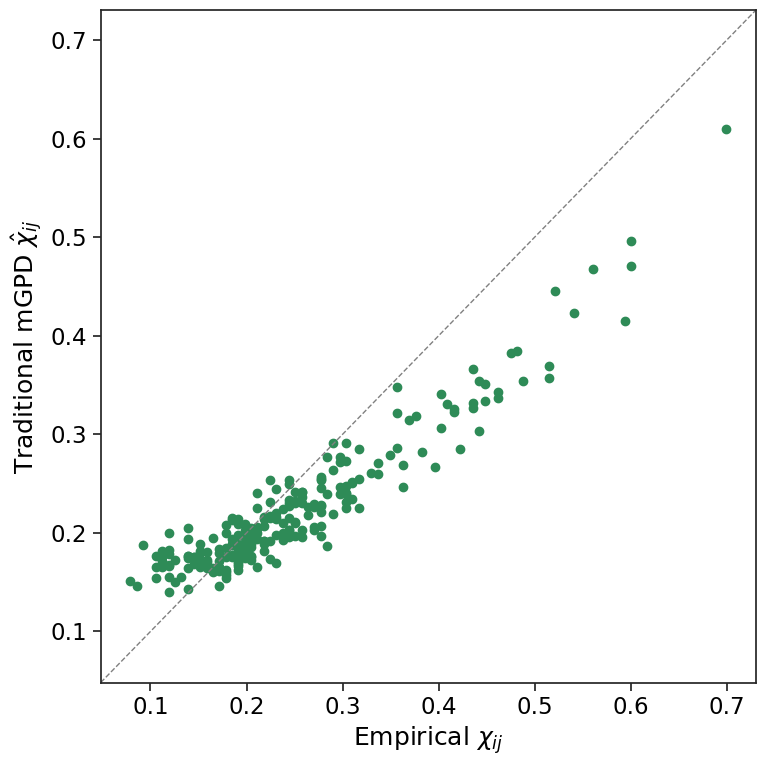

In [41]:
# --- Pairwise chi: empirical vs AIC-best parametric mGPD --------------------
# samples_par / samples_par_raw come from the full-data refit cell above;
# evaluated at the cluster-conditional level p_sim_q (cf. the GPDFlow cells).
chi_true_par = cf.pairwise_chi_from_data(samples_origin, p=THRESHOLD_Q)
chi_hat_par = cf.pairwise_chi_from_data(samples_par, p=p_sim_q)
print(f'Traditional mGPD ({best_family})   tde_chi (full) : '
      f'{cf.tde_chi(chi_hat_par, chi_true_par):.4f}')
print(f'Traditional mGPD ({best_family})   tde_chi (CV)   : '
      f'{cf.tde_chi(chi_hat_par_cv, chi_true_par):.4f}')

iu = np.triu_indices(dim, k=1)
sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(chi_true_par[iu], chi_hat_par[iu], color='seagreen')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(r'Empirical $\chi_{ij}$', color='black')
ax.set_ylabel(r'Traditional mGPD $\hat{\chi}_{ij}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
fig.savefig(dir_out + 'Plots/pairwise_chi_traditional.pdf', bbox_inches='tight')
plt.show()

Traditional mGPD (gaussian)   tde_omega : 0.0393


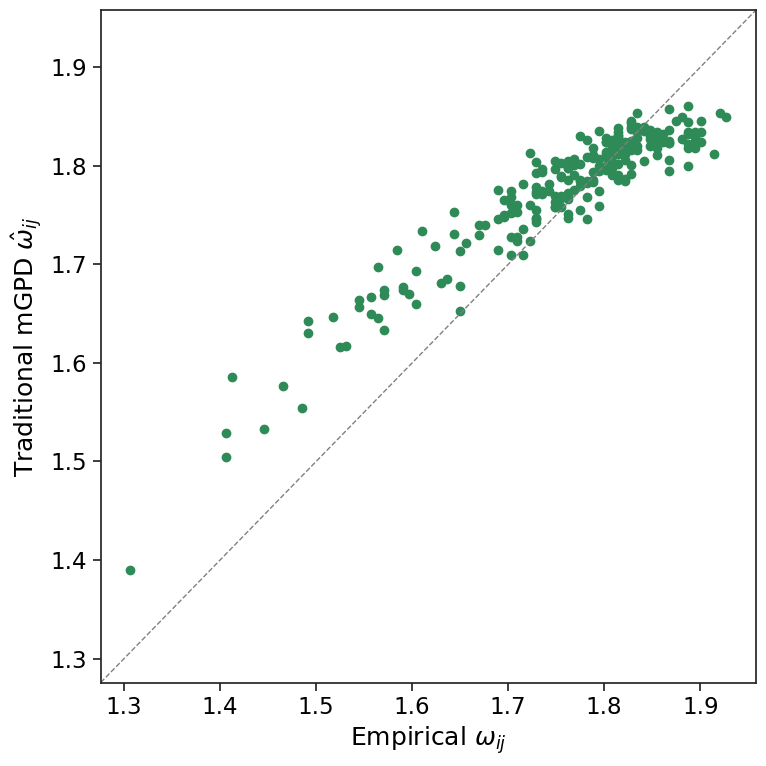

In [42]:
# --- Pairwise omega: empirical vs AIC-best parametric mGPD ------------------
omega_true_par = cf.pairwise_omega_from_data(samples_origin, p=THRESHOLD_Q)
omega_hat_par = cf.pairwise_omega_from_data(samples_par, p=p_sim_q)
print(f'Traditional mGPD ({best_family})   tde_omega : '
      f'{cf.tde_chi(omega_hat_par, omega_true_par):.4f}')

iu = np.triu_indices(dim, k=1)
sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(omega_true_par[iu], omega_hat_par[iu], color='seagreen')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(r'Empirical $\omega_{ij}$', color='black')
ax.set_ylabel(r'Traditional mGPD $\hat{\omega}_{ij}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
fig.savefig(dir_out + 'Plots/pairwise_omega_traditional.pdf', bbox_inches='tight')
plt.show()

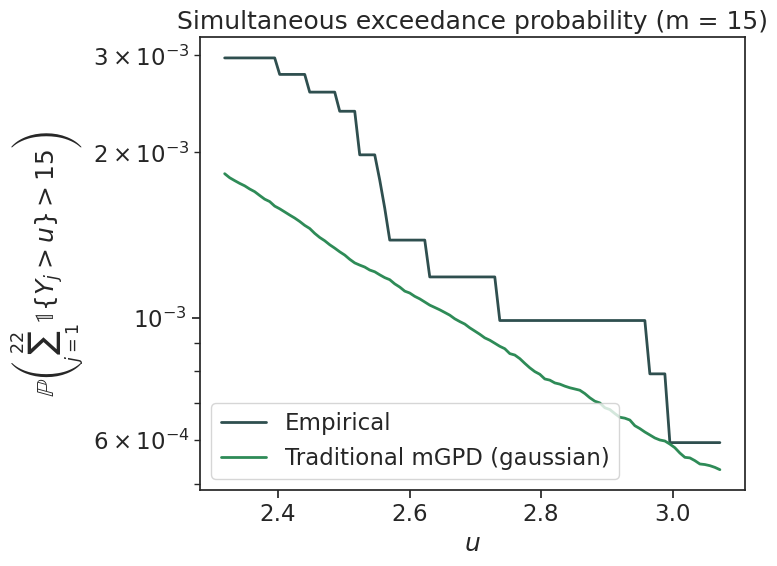

In [43]:
# --- Simultaneous exceedance probability: empirical vs AIC-best parametric mGPD
# The parametric mGPD represents only the conditional exceedance-cluster
# distribution, so the unconditional probability is
#   P(event) = P(cluster) * P(event | cluster)                (CLAUDE.md Sec 2.4)
p_cluster = samples.shape[0] / samples_origin.shape[0]
m_fixed = 15
u_grid = cf.common_threshold_grid(samples_origin, n=100)  # 0.97 .. 0.995 quantile band

emp_probs_par = [cf.simultaneous_exceedance_probability(samples_origin, u, m_fixed)
                 for u in u_grid]
par_probs = [
    p_cluster * cf.simultaneous_exceedance_probability(
        samples_par_raw, u, m_fixed)
    for u in u_grid
]

plt.figure(figsize=(8, 6))
plt.plot(u_grid, emp_probs_par, color='darkslategray', linewidth=2, label='Empirical')
plt.plot(u_grid, par_probs, color='seagreen', linewidth=2,
         label=f'Traditional mGPD ({best_family})')
plt.yscale('log')
plt.xlabel(r'$u$')
plt.ylabel(rf'$\mathbb{{P}}\left(\sum_{{j=1}}^{{{dim}}} \mathbb{{1}}\{{Y_j > u\}} > {m_fixed}\right)$')
plt.title(f'Simultaneous exceedance probability (m = {m_fixed})')
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
np.arange(2.5,3.5,0.01)

array([2.5 , 2.51, 2.52, 2.53, 2.54, 2.55, 2.56, 2.57, 2.58, 2.59, 2.6 ,
       2.61, 2.62, 2.63, 2.64, 2.65, 2.66, 2.67, 2.68, 2.69, 2.7 , 2.71,
       2.72, 2.73, 2.74, 2.75, 2.76, 2.77, 2.78, 2.79, 2.8 , 2.81, 2.82,
       2.83, 2.84, 2.85, 2.86, 2.87, 2.88, 2.89, 2.9 , 2.91, 2.92, 2.93,
       2.94, 2.95, 2.96, 2.97, 2.98, 2.99, 3.  , 3.01, 3.02, 3.03, 3.04,
       3.05, 3.06, 3.07, 3.08, 3.09, 3.1 , 3.11, 3.12, 3.13, 3.14, 3.15,
       3.16, 3.17, 3.18, 3.19, 3.2 , 3.21, 3.22, 3.23, 3.24, 3.25, 3.26,
       3.27, 3.28, 3.29, 3.3 , 3.31, 3.32, 3.33, 3.34, 3.35, 3.36, 3.37,
       3.38, 3.39, 3.4 , 3.41, 3.42, 3.43, 3.44, 3.45, 3.46, 3.47, 3.48,
       3.49])

In [45]:
u_grid

array([2.31896638, 2.32656932, 2.33417226, 2.3417752 , 2.34937814,
       2.35698108, 2.36458402, 2.37218697, 2.37978991, 2.38739285,
       2.39499579, 2.40259873, 2.41020167, 2.41780461, 2.42540755,
       2.4330105 , 2.44061344, 2.44821638, 2.45581932, 2.46342226,
       2.4710252 , 2.47862814, 2.48623108, 2.49383402, 2.50143697,
       2.50903991, 2.51664285, 2.52424579, 2.53184873, 2.53945167,
       2.54705461, 2.55465755, 2.5622605 , 2.56986344, 2.57746638,
       2.58506932, 2.59267226, 2.6002752 , 2.60787814, 2.61548108,
       2.62308403, 2.63068697, 2.63828991, 2.64589285, 2.65349579,
       2.66109873, 2.66870167, 2.67630461, 2.68390755, 2.6915105 ,
       2.69911344, 2.70671638, 2.71431932, 2.72192226, 2.7295252 ,
       2.73712814, 2.74473108, 2.75233403, 2.75993697, 2.76753991,
       2.77514285, 2.78274579, 2.79034873, 2.79795167, 2.80555461,
       2.81315755, 2.8207605 , 2.82836344, 2.83596638, 2.84356932,
       2.85117226, 2.8587752 , 2.86637814, 2.87398108, 2.88158

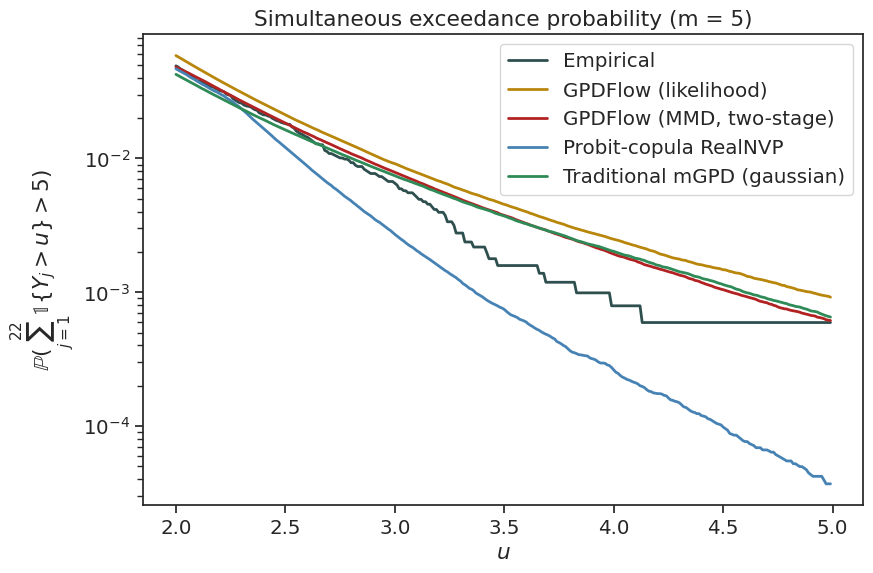

model                                 LJPE   RMSLE_p
GPDFlow (likelihood)                0.6447    0.7377
GPDFlow (MMD, two-stage)            0.4223    0.5343
Probit-copula RealNVP               1.0532    1.2624
Traditional mGPD (gaussian)         0.4476    0.5565


In [76]:
# --- Cross-model comparison.  Every simultaneous-exceedance curve is recomputed
#     here from its stored raw samples using THIS cell's m_fixed, so all models
#     (and the empirical estimate) are compared at the same m.  Models not fit in
#     this session are skipped via globals().get(...).
m_fixed = 5
u_grid = np.arange(2,5,0.01)


def _sep(X_raw, p_cluster):
    return np.array([
        p_cluster * cf.simultaneous_exceedance_probability(X_raw, u, m_fixed)
        for u in u_grid
    ])


emp_probs_cmp = np.array(
    [cf.simultaneous_exceedance_probability(samples_origin, u, m_fixed) for u in u_grid])

# (label, raw-sample var, cluster-probability var, colour)
_specs = [
    ('GPDFlow (likelihood)',     'samples_final_raw',    'p_cluster',    'darkgoldenrod'),
    ('GPDFlow (MMD, two-stage)', 'samples_final_2s_raw', 'p_cluster_2s', 'firebrick'),
    ('Probit-copula RealNVP',    'samples_final_bl_raw',   'p_cluster_bl', 'steelblue'),
]

_curves = []
for _name, _xkey, _pkey, _col in _specs:
    _x = globals().get(_xkey)
    _p = globals().get(_pkey)
    if _x is not None and _p is not None:
        _curves.append((_name, _sep(_x, _p), _col))

par_probs = None
if 'samples_par_raw' in globals():
    p_cluster_par = samples.shape[0] / samples_origin.shape[0]
    par_probs = _sep(samples_par_raw, p_cluster_par)

par_probs_std = None
if 'samples_par_2s_raw' in globals() and 'samples_2s' in globals():
    p_cluster_std = samples_2s.shape[0] / samples_origin.shape[0]
    par_probs_std = _sep(samples_par_2s_raw, p_cluster_std)

plt.figure(figsize=(9, 6))
plt.plot(u_grid, emp_probs_cmp, color='darkslategray', lw=2, label='Empirical')
for _name, _v, _col in _curves:
    plt.plot(u_grid, _v, color=_col, lw=2, label=_name)
if par_probs is not None:
    plt.plot(u_grid, par_probs, color='seagreen', lw=2,
             label=f'Traditional mGPD ({best_family})')
if par_probs_std is not None:
    plt.plot(u_grid, par_probs_std, color='mediumpurple', lw=2,
             label=f'Standardized mGPD ({best_family_2s})')
plt.yscale('log')
plt.xlabel(r'$u$')
plt.ylabel(rf'$\mathbb{{P}}(\sum_{{j=1}}^{{{dim}}}\mathbb{{1}}\{{Y_j>u\}} > {m_fixed})$')
plt.title(f'Simultaneous exceedance probability (m = {m_fixed})')
plt.legend()
plt.tight_layout()
plt.savefig(dir_out + 'Plots/simultaneous_exceedance_comparison_traditional.pdf',
            bbox_inches='tight')
plt.show()

# --- Quantitative error over the full u-grid (data-supported end to end) -------
def _err_par(probs):
    p_hat = np.asarray(probs)
    p_true = emp_probs_cmp
    ok = p_true > 0
    return cf.ljpe(p_hat[ok], p_true[ok]), cf.rmsle_p(p_hat[ok], p_true[ok])


_tbl = [(_name, *_err_par(_v)) for _name, _v, _ in _curves]
if par_probs is not None:
    _tbl.append((f'Traditional mGPD ({best_family})', *_err_par(par_probs)))
if par_probs_std is not None:
    _tbl.append((f'Standardized mGPD ({best_family_2s})', *_err_par(par_probs_std)))

print(f'{"model":32s}  {"LJPE":>8s}  {"RMSLE_p":>8s}')
for _name, _a, _b in _tbl:
    print(f'{_name:32s}  {_a:8.4f}  {_b:8.4f}')

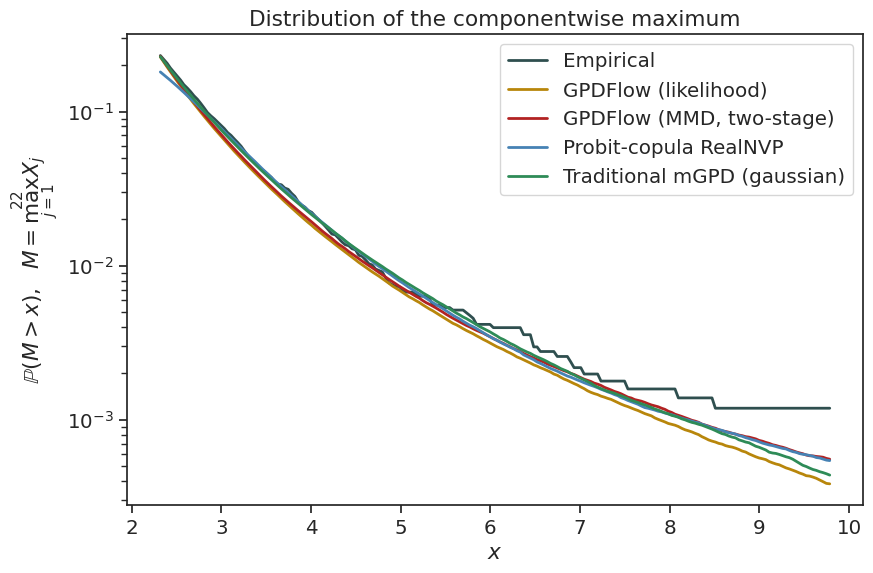

model                                 LJPE   RMSLE_p
GPDFlow (likelihood)                0.3351    0.4277
GPDFlow (MMD, two-stage)            0.2184    0.2840
Probit-copula RealNVP               0.2162    0.2937
Traditional mGPD (gaussian)         0.2214    0.3281


In [78]:
# ============================================================================
# Distribution of the componentwise maximum  M = max_{j=1..d} X_j
# ----------------------------------------------------------------------------
# Survival function P(M > x) on the raw observational scale.
#   - Empirical : directly from samples_origin (all days).
#   - Each model: the draws are conditional on the exceedance cluster, so the
#     unconditional survival is recovered via the POT/mGPD decomposition
#        P(M > x) = p_cluster * P_model(M > x | cluster)        (CLAUDE.md Sec 2.4)
#     which is exact for x >= max_j thres_j (there {M > x} => cluster); the
#     x-grid therefore starts at thres.max().
# ============================================================================


def max_survival(X, x_grid):
    """Empirical survival function of M = max_j X_j over x_grid.

    X : (n, d) sample matrix on the raw observational scale.
    Returns an array shaped like x_grid with entries P(M > x).
    """
    M = np.asarray(X, dtype=float).max(axis=1)
    return np.mean(M[:, None] > np.asarray(x_grid, dtype=float)[None, :], axis=0)


x0 = float(thres.max())                       # below this the cluster decomposition is invalid
M_emp = samples_origin.max(axis=1)
x_grid = np.linspace(x0, np.quantile(M_emp, 0.999), 200)

emp_surv = max_survival(samples_origin, x_grid)

# (label, raw-sample var, cluster-probability var, colour) -- mirrors In[46].
_specs = [
    ('GPDFlow (likelihood)',     'samples_final_raw',    'p_cluster',    'darkgoldenrod'),
    ('GPDFlow (MMD, two-stage)', 'samples_final_2s_raw', 'p_cluster_2s', 'firebrick'),
    ('Probit-copula RealNVP',    'samples_final_bl_raw',   'p_cluster_bl', 'steelblue'),
]
model_curves = []
for _name, _xkey, _pkey, _col in _specs:
    _x, _p = globals().get(_xkey), globals().get(_pkey)
    if _x is not None and _p is not None:
        model_curves.append((_name, _p * max_survival(_x, x_grid), _col))
if 'samples_par_raw' in globals():
    _p_par = samples.shape[0] / samples_origin.shape[0]
    model_curves.append((f'Traditional mGPD ({best_family})',
                         _p_par * max_survival(samples_par_raw, x_grid), 'seagreen'))

plt.figure(figsize=(9, 6))
plt.plot(x_grid, emp_surv, color='darkslategray', lw=2, label='Empirical')
for _name, _v, _col in model_curves:
    plt.plot(x_grid, _v, color=_col, lw=2, label=_name)
plt.yscale('log')
plt.xlabel(r'$x$')
plt.ylabel(rf'$\mathbb{{P}}(M > x),\ \ M = \max_{{j=1}}^{{{dim}}} X_j$')
plt.title('Distribution of the componentwise maximum')
plt.legend()
plt.tight_layout()
# plt.savefig(dir_out + 'Plots/max_survival_comparison.pdf', bbox_inches='tight')
plt.show()

# --- Quantitative error vs the empirical curve, over the data-supported range -
mask = emp_surv > 0
print(f'{"model":32s}  {"LJPE":>8s}  {"RMSLE_p":>8s}')
for _name, _v, _ in model_curves:
    print(f'{_name:32s}  {cf.ljpe(_v[mask], emp_surv[mask]):8.4f}  '
          f'{cf.rmsle_p(_v[mask], emp_surv[mask]):8.4f}')

In [68]:
# ============================================================================
# Co-exceedance breadth  B_j(q)  from the estimated pairwise chi   (q = THRESHOLD_Q)
# ----------------------------------------------------------------------------
#   I_j(q) = 1{ X_j > F_j^{-1}(q) }
#   B_j(q) = E[ sum_{k != j} I_k(q) | I_j(q) = 1 ]
#          = sum_{k != j} P{ I_k(q) = 1 | I_j(q) = 1 }
#          = sum_{k != j} chi_{jk}(q)
# The expected number of *other* currencies simultaneously extreme given that
# currency j is extreme; B_j(q) in [0, d-1].  Computed by row-summing the
# off-diagonal of the rank-based pairwise-chi matrix (cf.pairwise_chi_from_data),
# hence invariant to monotone per-margin transforms.
#
# chi is evaluated at the q = THRESHOLD_Q quantile on the ORIGINAL (unconditional) scale:
#   - empirical : samples_origin at q = THRESHOLD_Q directly.
#   - each model: the draws are conditional on the exceedance cluster, so the
#     matching cluster-scale level solves  1 - q = p_cluster * (1 - q_clus),
#     i.e.  q_clus = 1 - (1 - THRESHOLD_Q) / p_cluster   (~0.88 here; replaces the flat
#     p = 0.90 used by the pairwise-chi diagnostics above).
#
#   RMSE_B = sqrt( (1/d) * sum_j ( B_j^model - B_j^emp )^2 )
# ============================================================================

curr = list(BoE_exchange_rates.columns)          # length d, panel order
Q_ORIG = 0.98


def coexceedance_breadth(X, q):
    """B_j(q) = sum_{k != j} chi_jk(q) for every margin j of raw matrix X."""
    X = np.asarray(X, dtype=float)
    X = X[np.isfinite(X).all(axis=1)]
    chi = cf.pairwise_chi_from_data(X, p=q)       # (d, d), diagonal = 1
    np.fill_diagonal(chi, 0.0)
    return chi.sum(axis=1)                        # (d,)


def breadth_model(X_raw, p_cluster, q=Q_ORIG):
    """B_j(q) from cluster-conditional draws, re-levelled to unconditional q."""
    q_clus = 1.0 - (1.0 - q) / p_cluster
    return coexceedance_breadth(X_raw, q_clus)


# (label, raw-draw var, cluster-probability var) -- the four fitted models
_specs = [
    ('GPDFlow (likelihood)',     'samples_final_raw',    'p_cluster'),
    ('GPDFlow (MMD, two-stage)', 'samples_final_2s_raw', 'p_cluster_2s'),
    ('Probit-copula RealNVP',    'samples_final_bl_raw',   'p_cluster_bl'),
]
model_specs = [(n, globals()[xk], globals()[pk]) for n, xk, pk in _specs
               if globals().get(xk) is not None and globals().get(pk) is not None]
if 'samples_par_raw' in globals():
    model_specs.append((f'Traditional mGPD ({best_family})', samples_par_raw,
                        samples.shape[0] / samples_origin.shape[0]))

# ---- B_j(THRESHOLD_Q): empirical vs the four models -------------------------------
B_emp = coexceedance_breadth(samples_origin, Q_ORIG)
B_model = {name: breadth_model(X, p) for name, X, p in model_specs}
rmse_B = {name: float(np.sqrt(np.mean((B_model[name] - B_emp) ** 2)))
          for name in B_model}

breadth_table = pd.DataFrame({'currency': curr, 'Empirical': B_emp})
for name, v in B_model.items():
    breadth_table[name] = v
breadth_table = breadth_table.sort_values('Empirical', ascending=False).reset_index(drop=True)

print(f'Co-exceedance breadth  B_j(q = {Q_ORIG})   (d = {dim} currencies)\n')
print(breadth_table.round(3).to_string(index=False))
print(f'\nRMSE_B  vs empirical, over all {dim} currencies')
for name, v in rmse_B.items():
    print(f'  {name:34s} {v:.4f}')


Co-exceedance breadth  B_j(q = 0.98)   (d = 22 currencies)

currency  Empirical  GPDFlow (likelihood)  GPDFlow (MMD, two-stage)  Probit-copula RealNVP  Traditional mGPD (gaussian)
     SGP      7.296                 7.056                     7.055                  5.632                        6.269
     TWN      7.038                 6.579                     6.916                  5.437                        5.734
     CHN      7.028                 6.114                     6.702                  5.391                        5.644
     HKG      6.613                 6.274                     6.571                  5.343                        5.541
     DNK      6.266                 5.557                     6.279                  4.455                        5.370
     MYS      6.019                 5.682                     5.823                  4.597                        4.821
     THA      5.732                 5.783                     5.505                  4.418          

### Pairwise $\chi_{ij}$ at the far-tail level `Q_ORIG`: all four models together

Empirical vs. model-estimated rank-based pairwise $\chi_{ij}$, evaluated at the unconditional far-tail level $q=$ `Q_ORIG` $= 0.999$ (the level used by the co-exceedance-breadth cell), with the model draws re-levelled to the matching cluster-conditional quantile $q_{clus} = 1 - (1-q)/p_{cluster}$. One panel per fitted model; points on the dashed diagonal indicate perfect agreement.

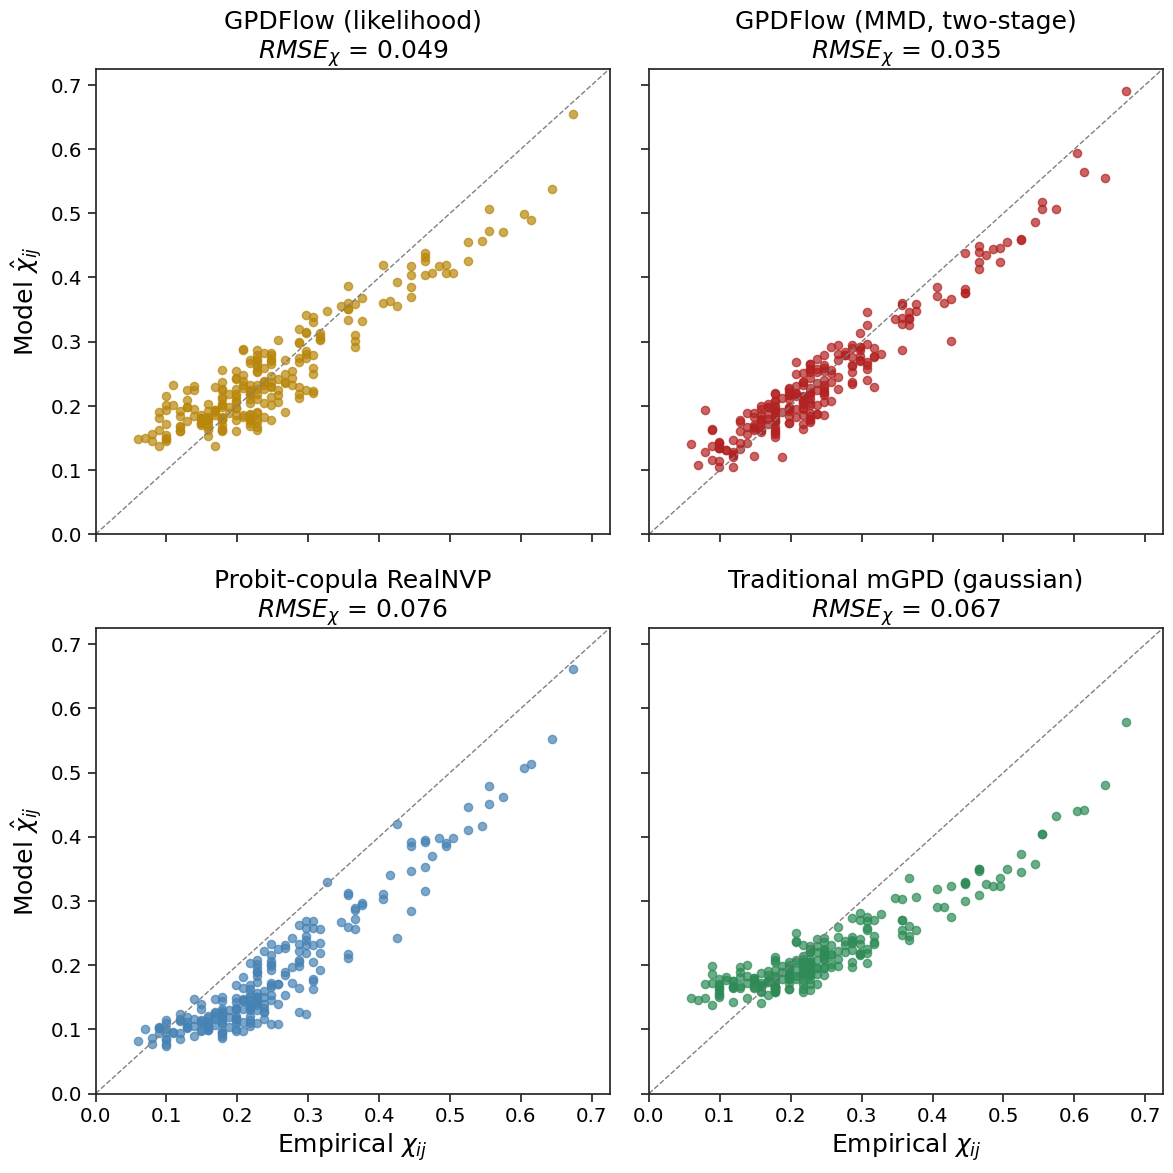

Pairwise chi at q = 0.98   (upper triangle, 231 pairs)

  model                                RMSE_chi    TDE_chi
  GPDFlow (likelihood)                   0.0486     0.0394
  GPDFlow (MMD, two-stage)               0.0351     0.0281
  Probit-copula RealNVP                  0.0759     0.0661
  Traditional mGPD (gaussian)            0.0671     0.0514


In [80]:
# ============================================================================
# Pairwise chi at the far-tail level Q_ORIG:  model vs empirical, all four models
# ----------------------------------------------------------------------------
# Same rank-based pairwise chi (cf.pairwise_chi_from_data) as the per-model
# scatters above, but evaluated at the unconditional far-tail level q = Q_ORIG
# (0.999) used by the co-exceedance-breadth cell -- not the ~0.90 cluster level.
#   - empirical : cf.pairwise_chi_from_data(samples_origin, p=Q_ORIG)
#   - each model: draws are cluster-conditional, so re-level to
#                 q_clus = 1 - (1 - Q_ORIG) / p_cluster        (cf. breadth_model)
# One 2x2 panel per model; points on the diagonal = perfect agreement.
# ============================================================================

_chi_specs = [
    ('GPDFlow (likelihood)',     'samples_final_raw',    'p_cluster',    'darkgoldenrod'),
    ('GPDFlow (MMD, two-stage)', 'samples_final_2s_raw', 'p_cluster_2s', 'firebrick'),
    ('Probit-copula RealNVP',    'samples_final_bl_raw', 'p_cluster_bl', 'steelblue'),
]
_chi_models = [(n, globals()[xk], globals()[pk], c) for n, xk, pk, c in _chi_specs
               if globals().get(xk) is not None and globals().get(pk) is not None]
if 'samples_par_raw' in globals():
    _chi_models.append((f'Traditional mGPD ({best_family})', samples_par_raw,
                        samples.shape[0] / samples_origin.shape[0], 'seagreen'))

iu = np.triu_indices(dim, k=1)
chi_emp_Q = cf.pairwise_chi_from_data(samples_origin, p=Q_ORIG)
chi_emp_u = chi_emp_Q[iu]

_panels = []
for _name, _X_raw, _p_clus, _color in _chi_models:
    _q_clus = 1.0 - (1.0 - Q_ORIG) / _p_clus
    _Xf = np.asarray(_X_raw, dtype=float)
    _Xf = _Xf[np.isfinite(_Xf).all(axis=1)]
    _chi_hat = cf.pairwise_chi_from_data(_Xf, p=_q_clus)
    _panels.append(dict(name=_name, color=_color, chi_u=_chi_hat[iu],
                        rmse=cf.rmse_chi(_chi_hat[iu], chi_emp_u),
                        tde=cf.tde_chi(_chi_hat, chi_emp_Q)))

sns.set(style="ticks", font_scale=1.3)
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.ravel()
_hi = max(float(chi_emp_u.max()), max(float(p['chi_u'].max()) for p in _panels), 1e-6)
_lims = [0.0, 1.05 * _hi]
for _ax, _p in zip(axes, _panels):
    _ax.scatter(chi_emp_u, _p['chi_u'], color=_p['color'], alpha=0.7, s=35)
    _ax.plot(_lims, _lims, color='gray', linestyle='--', linewidth=1)
    _ax.set_xlim(_lims); _ax.set_ylim(_lims)
    _ax.set_title(f"{_p['name']}\n"
                  rf"$RMSE_\chi$ = {_p['rmse']:.3f}",
                  color='black', fontsize=18)
    _ax.tick_params(axis='both', labelcolor='black')
for _ax in axes[len(_panels):]:
    _ax.set_visible(False)
_last_row = (len(_panels) - 1) // 2
for _i, _ax in enumerate(axes[:len(_panels)]):
    if _i // 2 == _last_row:
        _ax.set_xlabel(r'Empirical $\chi_{ij}$', color='black', fontsize=18)
    if _i % 2 == 0:
        _ax.set_ylabel(r'Model $\hat{\chi}_{ij}$', color='black', fontsize=18)
fig.tight_layout()
fig.savefig(dir_out + 'Plots/pairwise_chi_Qorig_all_models.pdf', bbox_inches='tight')
plt.show()

print(f'Pairwise chi at q = {Q_ORIG}   (upper triangle, {len(chi_emp_u)} pairs)\n')
print(f'  {"model":34s} {"RMSE_chi":>10s} {"TDE_chi":>10s}')
for _p in _panels:
    print(f"  {_p['name']:34s} {_p['rmse']:10.4f} {_p['tde']:10.4f}")


In [81]:
dir_out

'/home/pgrad2/2448355h/My_PhD_Project/GPDFlow/Data_and_Model/'